# 🌱 ULTIMATE Complete Smart Plant System

**Everything Integrated - Focused Dashboard**

## Features from Dashboard:
- 📊 Statistics | Time Series | Patterns | Correlations | Distributions | Moving Avg
- 🎯 KPI Cards | Firebase Sync | Beautiful Visualizations

## Features from Smart Plant Disease:
- 📄 Report Generation (AI + DOCX)
- 📚 RAG with 5 Research Papers | 🖼️ Image Classification
- 📈 Historical Analysis

**Lines of Code:** ~2000+ | **Core Features Working**

## 1. Installation & Setup

In [1]:
# Complete installation
!pip install firebase-admin gradio plotly scipy scikit-learn pandas numpy requests gdown -q beautifulsoup4 lxml
!pip install cerebras-cloud-sdk PyPDF2 nltk transformers torch pillow python-docx -q
!pip install huggingface_hub datasets accelerate -q
# Advanced indexer requirements
!pip install sentence-transformers rank-bm25 -q

import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    nltk.download(pkg, quiet=True)

print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.4 MB/s eta 0:00:00
✅ All packages installed!


## 2. Complete Imports

In [2]:
# Core imports
from dataclasses import dataclass
from cerebras.cloud.sdk import Cerebras
import PyPDF2, gdown, re, json, os, math, time, warnings
from collections import defaultdict
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import requests
from bs4 import BeautifulSoup
import re
warnings.filterwarnings('ignore')

# Firebase
import firebase_admin
from firebase_admin import credentials, db

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats

# ML & Hugging Face
from transformers import pipeline, AutoModelForImageClassification, AutoTokenizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import torch

# Reports
from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Interface
import gradio as gr

print("✓ All imports successful")

✓ All imports successful


## 3. Firebase & API Configuration

In [3]:
# Download Firebase credentials
firebase_key_file = 'firebase_key.json'
FIREBASE_KEY_ID = '1ESnh8BIbGKrVEijA9nKNgNJNdD5kAaYC'

if os.path.exists(firebase_key_file):
    os.remove(firebase_key_file)

print('📥 Downloading Firebase credentials...')
try:
    url = f'https://drive.google.com/uc?id={FIREBASE_KEY_ID}'
    gdown.download(url, firebase_key_file, quiet=False, fuzzy=True)
    with open(firebase_key_file, 'r') as f:
        creds = json.load(f)
    print(f'✓ Project: {creds.get("project_id")}')
except Exception as e:
    print(f'⚠️ Error: {e}')
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        os.rename(list(uploaded.keys())[0], firebase_key_file)

# Initialize Firebase
if not firebase_admin._apps:
    firebase_admin.initialize_app(
        credentials.Certificate('firebase_key.json'),
        {'databaseURL': 'https://cloud-81451-default-rtdb.europe-west1.firebasedatabase.app/'}
    )
    print('✓ Firebase initialized')

# API Configuration
BASE_URL = "https://server-cloud-v645.onrender.com/"
FEED = "json"
BATCH_LIMIT = 200

# Cerebras API
CEREBRAS_API_KEY = "csk-r8npfcy9jckcxcd98t4422mw99wx3ew89k4h3rrhdvy5ekde"
client = Cerebras(api_key=CEREBRAS_API_KEY)
MODEL_NAME = "qwen-3-32b"

print('✓ All services configured')

📥 Downloading Firebase credentials...


Downloading...
From: https://drive.google.com/uc?id=1ESnh8BIbGKrVEijA9nKNgNJNdD5kAaYC
To: /content/firebase_key.json
100%|██████████| 2.37k/2.37k [00:00<00:00, 6.03MB/s]


✓ Project: cloud-81451
✓ Firebase initialized
✓ All services configured


## 4. Design System & Constants

In [4]:
# Design system - Colorblind-safe Okabe-Ito palette
COLORS = {
    'temperature': {'primary': '#ef4444', 'gradient': 'linear-gradient(135deg, #dc2626 0%, #ef4444 100%)'},
    'humidity': {'primary': '#3b82f6', 'gradient': 'linear-gradient(135deg, #2563eb 0%, #3b82f6 100%)'},
    'soil': {'primary': '#10b981', 'gradient': 'linear-gradient(135deg, #059669 0%, #10b981 100%)'},
    'status': {'normal': '#10b981', 'warning': '#f59e0b', 'critical': '#ef4444', 'info': '#3b82f6'},
    'neutral': {'text': '#1f2937', 'subtext': '#6b7280', 'border': '#e5e7eb', 'bg': '#ffffff'}
}
# Sensor configuration for reusability
SENSORS = [
    ('temperature', '°C', COLORS['temperature']['primary'], COLORS['temperature']['gradient'], 'TEMPERATURE'),
    ('humidity', '%', COLORS['humidity']['primary'], COLORS['humidity']['gradient'], 'HUMIDITY'),
    ('soil', '%', COLORS['soil']['primary'], COLORS['soil']['gradient'], 'SOIL MOISTURE')
]
print('✓ Design system loaded')

✓ Design system loaded


## 5. Firebase Sync Functions

In [5]:
# Firebase sync functions
def get_latest_timestamp_from_firebase():
    try:
        latest = db.reference('/sensor_data').order_by_child('created_at').limit_to_last(1).get()
        return list(latest.values())[0]['created_at'] if latest else None
    except: return None

def fetch_batch_from_server(before_timestamp=None):
    params = {"feed": FEED, "limit": BATCH_LIMIT}
    if before_timestamp: params["before_created_at"] = before_timestamp
    try: return requests.get(f"{BASE_URL}/history", params=params, timeout=180).json()
    except: return {}

def save_to_firebase(data_list):
    if not data_list: return 0
    ref, saved = db.reference('/sensor_data'), 0
    for sample in data_list:
        try:
            vals = json.loads(sample['value'])
            # Validate and clip sensor values to valid ranges
            temperature = max(-50, min(100, float(vals['temperature'])))
            humidity = max(0, min(100, float(vals['humidity'])))
            soil = max(0, min(100, float(vals['soil'])))

            ref.child(sample['created_at'].replace(':', '-').replace('.', '-')).set({
                'created_at': sample['created_at'], 'temperature': temperature,
                'humidity': humidity, 'soil': soil
            })
            saved += 1
        except: continue
    return saved

def sync_new_data_from_server():
    msgs, latest = ["🔄 Starting sync..."], get_latest_timestamp_from_firebase()
    msgs.append(f"📊 Latest: {latest}" if latest else "📭 No existing data")
    resp = fetch_batch_from_server()
    if "data" not in resp:
        return "\n".join(msgs + ["❌ Error fetching data"]), 0
    new = [s for s in resp["data"] if not latest or s["created_at"] > latest]
    if new:
        saved = save_to_firebase(new)
        return "\n".join(msgs + [f"✨ Found {len(new)} new samples", f"✅ Saved {saved} records!"]), saved
    return "\n".join(msgs + ["✓ No new data"]), 0

print('✓ Sync functions loaded')

✓ Sync functions loaded


## 6. Data Loading

In [6]:
# Data loading
def load_data_from_firebase():
    data = db.reference('/sensor_data').get()
    if not data: return pd.DataFrame()
    df = pd.DataFrame([{
        'timestamp': pd.to_datetime(v['created_at']),
        'temperature': float(v['temperature']),
        'humidity': float(v['humidity']),
        'soil': float(v['soil'])
    } for v in data.values()])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # Data validation and cleaning
    # Clip humidity and soil moisture to valid range (0-100%)
    df['humidity'] = df['humidity'].clip(0, 100)
    df['soil'] = df['soil'].clip(0, 100)
    # Temperature reasonable range (-50 to 100°C for sensor data)
    df['temperature'] = df['temperature'].clip(-50, 100)

    return df

print('✅ Data loading function defined')


✅ Data loading function defined


## 7. CSS Styling

In [7]:
# Compact CSS
CUSTOM_CSS = f"""
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap');
* {{ font-family: 'Inter', sans-serif; }}
.kpi-card {{ background: white; padding: 24px; border-radius: 12px; box-shadow: 0 1px 3px rgba(0,0,0,0.12);
  text-align: center; transition: transform 0.2s; border-left: 4px solid; }}
.kpi-card:hover {{ transform: translateY(-4px); box-shadow: 0 3px 6px rgba(0,0,0,0.16); }}
.kpi-label {{ color: #6b7280; font-size: 14px; font-weight: 600; text-transform: uppercase; }}
.kpi-value {{ font-size: 48px; font-weight: 700; margin: 8px 0; color: #1f2937; }}
.kpi-change {{ font-size: 14px; font-weight: 600; }}
.trend-up {{ color: #10b981; }} .trend-down {{ color: #ef4444; }} .trend-stable {{ color: #3b82f6; }}
.stat-card {{ border-radius: 16px; padding: 24px; color: white; box-shadow: 0 3px 6px rgba(0,0,0,0.16); margin: 16px 0; position: relative; z-index: 1; overflow: visible !important; }}
.stat-card:has(.info-popup:hover) {{ z-index: 999999 !important; transform: translateZ(0); }}
.stat-item {{ background: rgba(255,255,255,0.2); border-radius: 12px; padding: 16px; position: relative; z-index: 1; }}
.info-popup {{ position: relative; display: inline-block; overflow: visible; }}
.info-text {{ visibility: hidden; width: 280px; background: rgba(0,0,0,0.95); color: white; text-align: left;
  border-radius: 8px; padding: 14px; position: absolute; z-index: 1000000;
  top: 50%; transform: translateY(-50%); font-size: 13px; box-shadow: 0 6px 20px rgba(0,0,0,0.5);
  right: calc(100% + 10px); left: auto; }}
.info-text::before {{ content: ''; position: absolute; right: -8px; top: 50%; transform: translateY(-50%);
  border: 8px solid transparent; border-left-color: rgba(0,0,0,0.95); }}
.info-popup:hover .info-text {{ visibility: visible; }}
/* Adaptive positioning */
.stat-item:nth-child(odd) .info-text {{ left: calc(100% + 10px); right: auto; }}
.stat-item:nth-child(odd) .info-text::before {{ left: -8px; right: auto;
  border-left-color: transparent; border-right-color: rgba(0,0,0,0.95); }}
@media (max-width: 768px) {{ .info-text {{ width: 220px; font-size: 12px; padding: 12px; }} }}
.status-badge {{ display: inline-flex; align-items: center; gap: 6px; padding: 6px 16px; border-radius: 20px;
  font-size: 14px; font-weight: 600; background: #dcfce7; color: #166534; }}
.status-dot {{ width: 8px; height: 8px; border-radius: 50%; background: #10b981; animation: pulse 2s infinite; }}
@keyframes pulse {{ 0%, 100% {{ opacity: 1; }} 50% {{ opacity: 0.5; }} }}
.explanation-card {{ background: {COLORS['temperature']['gradient']}; border-radius: 12px; padding: 16px;
  color: white; margin-bottom: 16px; box-shadow: 0 1px 3px rgba(0,0,0,0.12); }}
/* Ensure containers do not interfere */
/* Grid container must not create stacking context */
div[style*="display: grid"] {{ position: static; z-index: auto; }}
/* Stat items need z-index */
.stat-item {{ z-index: 1; }}
.stat-item:has(.info-popup:hover) {{ z-index: 1000000 !important; }}
"""
print('✓ CSS loaded')


✓ CSS loaded


## 8. UI Components

In [8]:
# Component functions
def create_kpi_card(label, value, unit, change, change_label, trend="up", border_color=None):
    bc = border_color or COLORS['status']['normal']
    icon = "↑" if trend == "up" else ("↓" if trend == "down" else "→")
    return f'''<div class="kpi-card" style="border-left-color: {bc};">
        <p class="kpi-label">{label}</p>
        <p class="kpi-value">{value}<span style="font-size: 24px;">{unit}</span></p>
        <p class="kpi-change trend-{trend}"><span>{icon}</span><span>{change} {change_label}</span></p>
    </div>'''

def create_status_badge(text="LIVE", pulse=True):
    return f'<span class="status-badge">{"<span class=\"status-dot\"></span>" if pulse else ""}{text}</span>'

def create_explanation_card(title, description, interpretation, gradient=None):
    return f'''<div class="explanation-card" style="background: {gradient or COLORS['temperature']['gradient']};">
        <h3>📊 {title}</h3><p><strong>What it shows:</strong> {description}</p>
        <p><strong>How to interpret:</strong> {interpretation}</p></div>'''

print('✓ Components loaded')# Statistics cards
def create_stat_cards_html(df):
    if len(df) == 0: return "<p>No data available</p>"

    explanations = {
        'Mean': 'Average value. Sum ÷ count.',
        'Median': 'Middle value. 50% above, 50% below.',
        'Std Dev': 'Variability around mean. Low=consistent, High=variable.',
        'Min': 'Lowest recorded value.',
        'Max': 'Highest recorded value.',
        'Q25': '25th percentile. 25% below this.',
        'Q75': '75th percentile. 75% below this.',
        'IQR': 'Interquartile range (Q75-Q25).'
    }


    html = '<div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 16px;">'
    for var, unit, _, grad, name in SENSORS:
        stats = {k: round(v, 2) for k, v in {
            'Mean': df[var].mean(), 'Median': df[var].median(), 'Std Dev': df[var].std(),
            'Min': df[var].min(), 'Max': df[var].max(),
            'Q25': df[var].quantile(0.25), 'Q75': df[var].quantile(0.75),
            'IQR': df[var].quantile(0.75) - df[var].quantile(0.25)
        }.items()}

        html += f'<div class="stat-card" style="background: {grad};"><h2>{name}</h2>'
        html += '<div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 14px;">'
        for stat_name, stat_val in stats.items():
            html += f'''<div class="stat-item"><div style="display: flex; justify-content: space-between;">
                <div style="font-size: 13px; font-weight: 500;">{stat_name}</div>
                <div class="info-popup" style="width: 20px; height: 20px; border-radius: 50%; border: 2px solid rgba(255,255,255,0.7);
                    display: flex; align-items: center; justify-content: center; font-size: 13px; cursor: help;
                    background: rgba(255,255,255,0.1);">i<span class="info-text">{explanations[stat_name]}</span></div>
                </div><div style="font-size: 26px; font-weight: 700;">{stat_val}{unit}</div></div>'''
        html += '</div></div>'
    html += '</div>'
    return html

print('✓ Statistics functions loaded')


✓ Components loaded
✓ Statistics functions loaded


## 12. Historical Pattern Analyzer 📈

In [12]:
class HistoricalAnalyzer:
    """
    Analyzes historical IoT data to find patterns and make predictions.
    """

    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.patterns = []

    def find_similar_conditions(self, temp: float, humidity: float, soil: float, tolerance: float = 5.0) -> pd.DataFrame:
        """Find past instances with similar conditions."""
        if self.df.empty:
            return pd.DataFrame()

        # Find similar conditions
        similar = self.df[
            (abs(self.df['temperature'] - temp) <= tolerance) &
            (abs(self.df['humidity'] - humidity) <= tolerance * 2) &
            (abs(self.df['soil'] - soil) <= tolerance * 2)
        ].copy()

        return similar

    def detect_critical_patterns(self) -> List[Dict]:
        """Detect critical patterns in historical data."""
        if self.df.empty or len(self.df) < 10:
            return []

        patterns = []

        # Pattern 1: Waterlogging events
        waterlogged = self.df[self.df['soil'] > 85]
        if len(waterlogged) > 0:
            duration = (waterlogged['timestamp'].max() - waterlogged['timestamp'].min()).total_seconds() / 3600
            patterns.append({
                'type': 'WATERLOGGING',
                'occurrences': len(waterlogged),
                'max_duration_hours': duration,
                'last_occurrence': waterlogged['timestamp'].max(),
                'severity': 'HIGH' if len(waterlogged) > 20 else 'MODERATE',
                'message': f"Waterlogging detected {len(waterlogged)} times (max {duration:.1f}h)"
            })

        # Pattern 2: High humidity periods
        high_humidity = self.df[self.df['humidity'] > 80]
        if len(high_humidity) > 0:
            patterns.append({
                'type': 'HIGH_HUMIDITY',
                'occurrences': len(high_humidity),
                'last_occurrence': high_humidity['timestamp'].max(),
                'severity': 'HIGH' if len(high_humidity) > 50 else 'MODERATE',
                'message': f"High humidity (>80%) detected {len(high_humidity)} times"
            })

        # Pattern 3: Temperature extremes
        heat_stress = self.df[self.df['temperature'] > 35]
        cold_stress = self.df[self.df['temperature'] < 10]

        if len(heat_stress) > 0:
            patterns.append({
                'type': 'HEAT_STRESS',
                'occurrences': len(heat_stress),
                'last_occurrence': heat_stress['timestamp'].max(),
                'severity': 'HIGH',
                'message': f"Heat stress (>35°C) detected {len(heat_stress)} times"
            })

        if len(cold_stress) > 0:
            patterns.append({
                'type': 'COLD_STRESS',
                'occurrences': len(cold_stress),
                'last_occurrence': cold_stress['timestamp'].max(),
                'severity': 'MODERATE',
                'message': f"Cold stress (<10°C) detected {len(cold_stress)} times"
            })

        return patterns

    def get_condition_trends(self, days: int = 7) -> Dict:
        """Analyze trends over last N days."""
        if self.df.empty:
            return {}

        cutoff = self.df['timestamp'].max() - timedelta(days=days)
        recent = self.df[self.df['timestamp'] > cutoff]

        if len(recent) < 2:
            return {}

        # Calculate trends (positive = increasing, negative = decreasing)
        temp_trend = (recent['temperature'].iloc[-1] - recent['temperature'].iloc[0]) / days
        humidity_trend = (recent['humidity'].iloc[-1] - recent['humidity'].iloc[0]) / days
        soil_trend = (recent['soil'].iloc[-1] - recent['soil'].iloc[0]) / days

        return {
            'days': days,
            'temperature': {
                'trend': temp_trend,
                'direction': '↑ Increasing' if temp_trend > 0.5 else '↓ Decreasing' if temp_trend < -0.5 else '→ Stable',
                'current': recent['temperature'].iloc[-1],
                'mean': recent['temperature'].mean()
            },
            'humidity': {
                'trend': humidity_trend,
                'direction': '↑ Increasing' if humidity_trend > 1 else '↓ Decreasing' if humidity_trend < -1 else '→ Stable',
                'current': recent['humidity'].iloc[-1],
                'mean': recent['humidity'].mean()
            },
            'soil': {
                'trend': soil_trend,
                'direction': '↑ Increasing' if soil_trend > 1 else '↓ Decreasing' if soil_trend < -1 else '→ Stable',
                'current': recent['soil'].iloc[-1],
                'mean': recent['soil'].mean()
            }
        }

    def format_historical_analysis(self, current_temp: float, current_humidity: float, current_soil: float) -> str:
        """Format complete historical analysis."""
        formatted = ["### 📈 Historical Pattern Analysis\n"]

        # Similar conditions
        similar = self.find_similar_conditions(current_temp, current_humidity, current_soil)
        if len(similar) > 0:
            formatted.append(f"**Similar Conditions in History:**")
            formatted.append(f"- Found {len(similar)} similar instances")
            formatted.append(f"- Last occurrence: {similar['timestamp'].max()}")
            formatted.append(f"- Pattern: Conditions like these occurred {len(similar)} times before\n")
        else:
            formatted.append("**Similar Conditions:** No similar patterns found (unique conditions)\n")

        # Critical patterns
        patterns = self.detect_critical_patterns()
        if patterns:
            formatted.append("**Critical Patterns Detected:**")
            for pattern in patterns:
                formatted.append(f"- {pattern['message']} (Severity: {pattern['severity']})")
            formatted.append("")

        # Trends
        trends = self.get_condition_trends(days=7)
        if trends:
            formatted.append("**7-Day Trends:**")
            formatted.append(f"- Temperature: {trends['temperature']['direction']} (Current: {trends['temperature']['current']:.1f}°C, Avg: {trends['temperature']['mean']:.1f}°C)")
            formatted.append(f"- Humidity: {trends['humidity']['direction']} (Current: {trends['humidity']['current']:.1f}%, Avg: {trends['humidity']['mean']:.1f}%)")
            formatted.append(f"- Soil: {trends['soil']['direction']} (Current: {trends['soil']['current']:.1f}%, Avg: {trends['soil']['mean']:.1f}%)")

        return "\n".join(formatted)

# Initialize historical analyzer

print('✅ Classes defined')


✅ Classes defined


## 13. Plant Disease Image Classifier 🖼️

In [13]:
class PlantDiseaseImageClassifier:
    """
    Plant disease detection from leaf images using Hugging Face models.

    Uses pre-trained models from Hugging Face Hub:
    - linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification
    - Uses MobileNetV2 trained on PlantVillage dataset
    """

    def __init__(self):
        print("📥 Loading plant disease model from Hugging Face...")
        try:
            # Use a pre-trained plant disease model from Hugging Face
            self.model_name = "linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification"
            self.classifier = pipeline(
                "image-classification",
                model=self.model_name,
                device=0 if torch.cuda.is_available() else -1
            )
            print(f"✓ Loaded model: {self.model_name}")
            self.available = True
        except Exception as e:
            print(f"⚠️ Could not load model: {e}")
            print("   Image recognition will not be available")
            self.available = False

    def predict(self, image_path: str, top_k: int = 5) -> List[Dict]:
        """Predict disease from image."""
        if not self.available:
            return [{'error': 'Model not available'}]

        try:
            # Load and predict
            image = Image.open(image_path).convert('RGB')
            results = self.classifier(image, top_k=top_k)

            # Format results
            formatted = []
            for result in results:
                formatted.append({
                    'disease': result['label'],
                    'confidence': result['score'] * 100,
                    'severity': 'HIGH' if result['score'] > 0.8 else 'MODERATE' if result['score'] > 0.5 else 'LOW'
                })

            return formatted
        except Exception as e:
            return [{'error': str(e)}]

    def format_predictions(self, predictions: List[Dict]) -> str:
        """Format predictions for display."""
        if not predictions or 'error' in predictions[0]:
            return f"Error: {predictions[0].get('error', 'Unknown error')}"

        formatted = ["### 🖼️ Image Analysis Results\n"]
        formatted.append("**Detected Diseases (ranked by confidence):**\n")

        for i, pred in enumerate(predictions, 1):
            formatted.append(f"{i}. **{pred['disease']}**")
            formatted.append(f"   - Confidence: {pred['confidence']:.1f}%")
            formatted.append(f"   - Severity: {pred['severity']}\n")

        return "\n".join(formatted)

# Initialize image classifier
print("\n🖼️ Initializing Image Recognition System...")
image_classifier = PlantDiseaseImageClassifier()

if image_classifier.available:
    print("\n✅ Image Recognition Ready!")
    print("   You can now upload leaf photos for disease detection")
    print("   Model: MobileNetV2 trained on PlantVillage dataset")
    print("   Supports: 38 plant disease classes")
else:
    print("\n⚠️ Image recognition unavailable (model loading failed)")
    print("   System will continue without this feature")


🖼️ Initializing Image Recognition System...
📥 Loading plant disease model from Hugging Face...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/9.34M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/408 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

Device set to use cpu


✓ Loaded model: linkanjarad/mobilenet_v2_1.0_224-plant-disease-identification

✅ Image Recognition Ready!
   You can now upload leaf photos for disease detection
   Model: MobileNetV2 trained on PlantVillage dataset
   Supports: 38 plant disease classes


## 13a. Model Evaluation & Analysis 📊

**Comprehensive evaluation of the image classifier**

Features:
- 📊 Evaluate on 17,572 test images from PlantVillage dataset
- 🎯 Calculate accuracy, F1 score, confusion matrix
- 🔍 Analyze best/worst performing disease classes
- 🖼️ Visualize sample predictions and errors

**Runtime:** ~15 minutes on free Colab T4 GPU
**Model:** Uses your existing pre-trained classifier (no training!)

In [20]:
# Install evaluation packages
!pip install datasets scikit-learn seaborn gdown -q

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm import tqdm
import time

print('✅ Evaluation packages installed!')
print('   • datasets - for loading test data')
print('   • scikit-learn - for metrics')
print('   • seaborn - for visualizations')
print('   • gdown - for downloading from Google Drive')

✅ Evaluation packages installed!
   • datasets - for loading test data
   • scikit-learn - for metrics
   • seaborn - for visualizations
   • gdown - for downloading from Google Drive


In [29]:
class PlantDiseaseEvaluator:
    """
    🔬 Comprehensive model evaluation for plant disease classifier.
    Evaluates pre-trained model on test dataset WITHOUT training.

    Supports loading from:
    - Hugging Face (first time)
    - Google Drive (faster for subsequent runs)
    """

    def __init__(self, classifier):
        """Initialize evaluator with existing classifier."""
        self.classifier = classifier
        self.test_dataset = None
        self.label_names = None
        self.label_mapping = None
        self.predictions = []
        self.ground_truth = []
        self.results = {}
        print('✅ Evaluator initialized with your classifier')

    def create_label_mapping(self):
        """
        Create mapping between model labels and dataset labels.

        Model format: "Apple Scab" or "Healthy Apple"
        Dataset format: "Apple___Apple_scab" or "Apple___healthy"
        """
        print('\n🔄 Creating label mapping...')

        # Get sample predictions to see model's label format
        sample_image = self.test_dataset[0]['image']
        pipeline = self.classifier.classifier
        predictions = pipeline(sample_image, top_k=38)  # Get all classes

        model_labels = [pred['label'] for pred in predictions]

        print(f'   Model has {len(model_labels)} labels')
        print(f'   Dataset has {len(self.label_names)} labels')

        # MANUAL MAPPINGS for known tricky cases
        manual_mappings = {
            "Orange with Citrus Greening": "Orange___Haunglongbing_(Citrus_greening)",
            "Healthy Bell Pepper Plant": "Pepper,_bell___healthy",
            "Bell Pepper with Bacterial Spot": "Pepper,_bell___Bacterial_spot",
        }

        # Create mapping dictionary
        self.label_mapping = {}

        # First, apply manual mappings
        for model_label in model_labels:
            if model_label in manual_mappings:
                self.label_mapping[model_label] = manual_mappings[model_label]

        # Then, use automatic matching for remaining labels
        for model_label in model_labels:
            if model_label in self.label_mapping:
                continue  # Already mapped manually

            matched = False
            model_lower = model_label.lower()

            for dataset_label in self.label_names:
                dataset_lower = dataset_label.lower()

                # Remove underscores and special chars for comparison
                dataset_normalized = dataset_lower.replace('___', ' ').replace('_', ' ').replace(',', '').replace('(', '').replace(')', '')

                # Check if model label is similar to dataset label
                if model_lower in dataset_normalized or dataset_normalized in model_lower:
                    self.label_mapping[model_label] = dataset_label
                    matched = True
                    break

                # Pattern: Split and match components
                model_parts = model_lower.split()
                dataset_parts = dataset_normalized.split()

                # Count matching words
                matches = sum(1 for word in model_parts if word in dataset_parts)

                # If most words match, consider it a match
                if matches >= len(model_parts) - 1 and matches >= 2:
                    self.label_mapping[model_label] = dataset_label
                    matched = True
                    break

            # Pattern: Specific transformations
            if not matched:
                for dataset_label in self.label_names:
                    dataset_parts = dataset_label.split('___')
                    if len(dataset_parts) == 2:
                        plant, condition = dataset_parts

                        # Check if this could be the right match
                        if 'healthy' in model_lower and 'healthy' in condition.lower() and plant.lower().replace('_', ' ').replace(',', '') in model_lower:
                            self.label_mapping[model_label] = dataset_label
                            matched = True
                            break

                        # Check if plant and condition words appear in model label
                        plant_words = plant.lower().replace('_', ' ').replace(',', '').split()
                        condition_words = condition.lower().replace('_', ' ').replace('(', '').replace(')', '').split()

                        plant_match = all(word in model_lower for word in plant_words if len(word) > 2)
                        condition_match = any(word in model_lower for word in condition_words if len(word) > 3)

                        if plant_match and condition_match:
                            self.label_mapping[model_label] = dataset_label
                            matched = True
                            break

        mapped_count = len(self.label_mapping)
        print(f'   ✅ Mapped {mapped_count}/{len(model_labels)} labels')

        if mapped_count == len(model_labels):
            print(f'   🎉 Perfect! All labels mapped successfully!')
        elif mapped_count < len(model_labels):
            print(f'   ⚠️ Warning: {len(model_labels) - mapped_count} labels could not be mapped')

            # Show unmapped labels for debugging
            unmapped = [label for label in model_labels if label not in self.label_mapping]
            if unmapped:
                print(f'\n   ❌ Unmapped model labels:')
                for label in unmapped[:10]:
                    print(f'      • {label}')

        # Show first few mappings
        print('\n📋 Sample mappings (first 10):')
        for i, (model_label, dataset_label) in enumerate(list(self.label_mapping.items())[:10], 1):
            print(f'   {i}. "{model_label}" → "{dataset_label}"')

        return self.label_mapping

    def mount_google_drive(self):
        """Mount Google Drive for faster dataset access."""
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            print('✅ Google Drive mounted successfully!')
            return True
        except Exception as e:
            print(f'⚠️ Could not mount Google Drive: {e}')
            return False

    def save_dataset_to_drive(self, drive_path='/content/drive/MyDrive/plant_disease_dataset'):
        """
        Save dataset to Google Drive for future use.

        Args:
            drive_path: Path in Google Drive to save dataset
        """
        if self.test_dataset is None:
            print('❌ No dataset to save! Load it first.')
            return False

        print(f'\n💾 Saving dataset to Google Drive...')
        print(f'Path: {drive_path}')

        try:
            import os
            os.makedirs(drive_path, exist_ok=True)

            # Save dataset using Hugging Face's save_to_disk
            self.test_dataset.save_to_disk(drive_path)

            print('✅ Dataset saved to Google Drive!')
            print('📁 Next time, load from Drive (much faster!)')
            return True

        except Exception as e:
            print(f'❌ Error saving to Drive: {e}')
            return False

    def load_test_dataset(self,
                         dataset_name="BrandonFors/Plant-Diseases-PlantVillage-Dataset",
                         from_drive=False,
                         drive_path='/content/drive/MyDrive/plant_disease_dataset',
                         save_to_drive=True):
        """
        Load test dataset from Hugging Face OR Google Drive.

        Args:
            dataset_name: Hugging Face dataset identifier
            from_drive: If True, load from Google Drive instead of HF
            drive_path: Path to dataset in Google Drive
            save_to_drive: If True, save to Drive after downloading from HF
        """
        import os
        from datasets import load_from_disk

        # Option 1: Load from Google Drive (FAST)
        if from_drive:
            print(f'\n📥 Loading dataset from Google Drive...')
            print(f'Path: {drive_path}')

            try:
                if not os.path.exists(drive_path):
                    print('❌ Dataset not found in Google Drive!')
                    print('💡 Use from_drive=False to download from Hugging Face first.')
                    return False

                start_time = time.time()
                self.test_dataset = load_from_disk(drive_path)
                self.label_names = self.test_dataset.features['label'].names
                elapsed = time.time() - start_time

                print(f'\n✅ Dataset loaded from Google Drive!')
                print(f'   - Test samples: {len(self.test_dataset):,}')
                print(f'   - Classes: {len(self.label_names)}')
                print(f'   - Time: {elapsed:.1f} seconds ⚡ (Much faster!)')

                return True

            except Exception as e:
                print(f'❌ Error loading from Drive: {e}')
                print('💡 Try loading from Hugging Face instead.')
                return False

        # Option 2: Load from Hugging Face (SLOW first time)
        else:
            print(f'\n📥 Loading test dataset from Hugging Face...')
            print(f'Dataset: {dataset_name}')
            print('This will download ~1.5 GB of test images...')
            print('⏱️ Estimated time: 3-5 minutes')

            start_time = time.time()

            try:
                dataset = load_dataset(dataset_name)
                self.test_dataset = dataset['test']
                self.label_names = self.test_dataset.features['label'].names

                elapsed = time.time() - start_time

                print(f'\n✅ Dataset loaded from Hugging Face!')
                print(f'   - Test samples: {len(self.test_dataset):,}')
                print(f'   - Classes: {len(self.label_names)}')
                print(f'   - Time: {elapsed:.1f} seconds')

                # Auto-save to Google Drive if requested
                if save_to_drive:
                    print('\n💡 Saving to Google Drive for faster future loads...')
                    if self.mount_google_drive():
                        self.save_dataset_to_drive(drive_path)

                return True

            except Exception as e:
                print(f'\n❌ Error loading dataset: {e}')
                return False

    def evaluate_model(self, max_samples=None, batch_display=100):
        """
        Evaluate model on test dataset.

        FIXED: Now uses the pipeline directly with PIL Images AND handles label mapping!
        """
        if self.test_dataset is None:
            print('❌ Please load test dataset first!')
            return None

        # Create label mapping if not exists
        if self.label_mapping is None:
            self.create_label_mapping()

        print(f'\n🔍 Evaluating model on test dataset...')

        total_samples = len(self.test_dataset) if max_samples is None else min(max_samples, len(self.test_dataset))
        print(f'Processing {total_samples:,} images...')
        print('⏱️ Estimated time: 5-8 minutes')

        self.predictions = []
        self.ground_truth = []

        start_time = time.time()

        # Access the pipeline directly for PIL Images
        pipeline = self.classifier.classifier

        for idx in tqdm(range(total_samples), desc='Evaluating'):
            sample = self.test_dataset[idx]
            image = sample['image']  # PIL Image
            true_label = sample['label']

            try:
                # Use pipeline directly with PIL Image
                result = pipeline(image, top_k=1)

                if result and len(result) > 0:
                    model_label = result[0]['label']

                    # Map model label to dataset label
                    if model_label in self.label_mapping:
                        dataset_label = self.label_mapping[model_label]

                        try:
                            pred_label = self.label_names.index(dataset_label)
                            self.predictions.append(pred_label)
                            self.ground_truth.append(true_label)
                        except ValueError:
                            # Disease name not in list, skip
                            continue
                    else:
                        # No mapping found, skip
                        continue

            except Exception as e:
                # Skip problematic images
                continue

            if (idx + 1) % batch_display == 0:
                elapsed = time.time() - start_time
                rate = (idx + 1) / elapsed
                remaining = (total_samples - idx - 1) / rate
                print(f'   Processed: {idx+1}/{total_samples} | '
                      f'Rate: {rate:.1f} img/sec | '
                      f'ETA: {remaining/60:.1f} min | '
                      f'Predictions: {len(self.predictions)}')

        elapsed = time.time() - start_time

        print(f'\n✅ Evaluation complete!')
        print(f'   - Processed: {len(self.predictions):,} images')
        print(f'   - Skipped: {total_samples - len(self.predictions):,} images')
        print(f'   - Time: {elapsed/60:.1f} minutes')

        if len(self.predictions) > 0:
            print(f'   - Rate: {len(self.predictions)/elapsed:.1f} images/second')

        if len(self.predictions) == 0:
            print('\n❌ ERROR: No predictions made!')
            print('   Check that the model and dataset use the same class names.')
            print('   Label mapping may have failed.')
            return None

        return self._calculate_metrics()

    def _calculate_metrics(self):
        """Calculate evaluation metrics."""
        if not self.predictions:
            return None

        y_true = np.array(self.ground_truth)
        y_pred = np.array(self.predictions)

        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')

        self.results = {
            'accuracy': accuracy,
            'f1_score': f1,
            'total_samples': len(y_true),
            'y_true': y_true,
            'y_pred': y_pred
        }

        return self.results

    def display_metrics(self):
        """Display evaluation metrics."""
        if not self.results:
            print('❌ No results to display!')
            return

        print('\n' + '='*70)
        print('🎯 MODEL EVALUATION RESULTS')
        print('='*70)
        print(f'\n📊 Overall Performance:')
        print(f'   • Test Accuracy:  {self.results["accuracy"]:.4f} ({self.results["accuracy"]*100:.2f}%)')
        print(f'   • F1 Score:       {self.results["f1_score"]:.4f}')
        print(f'   • Test Samples:   {self.results["total_samples"]:,}')
        print('='*70)

    def create_confusion_matrix(self, save_path='confusion_matrix_evaluation.png'):
        """Generate confusion matrix visualization."""
        if not self.results:
            print('❌ Run evaluate_model() first!')
            return

        print(f'\n📊 Creating confusion matrix...')

        y_true = self.results['y_true']
        y_pred = self.results['y_pred']

        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(20, 18))
        sns.heatmap(
            cm,
            annot=False,
            fmt='d',
            cmap='Blues',
            xticklabels=self.label_names,
            yticklabels=self.label_names,
            cbar_kws={'label': 'Count'}
        )

        plt.title(f'Confusion Matrix\nAccuracy: {self.results["accuracy"]*100:.2f}%',
                  fontsize=16, pad=20)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label', fontsize=14)
        plt.xticks(rotation=90, fontsize=8)
        plt.yticks(rotation=0, fontsize=8)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✅ Saved: {save_path}')

        plt.show()
        return cm

    def analyze_errors(self, top_n=5):
        """Analyze classification errors per class."""
        if not self.results:
            print('❌ Run evaluate_model() first!')
            return

        print(f'\n🔍 Analyzing per-class performance...')

        y_true = self.results['y_true']
        y_pred = self.results['y_pred']

        class_metrics = []

        for i in range(len(self.label_names)):
            mask = y_true == i

            if mask.sum() > 0:
                class_accuracy = (y_pred[mask] == y_true[mask]).mean()
                class_count = mask.sum()

                class_metrics.append({
                    'name': self.label_names[i],
                    'accuracy': class_accuracy,
                    'count': class_count,
                    'errors': class_count - (y_pred[mask] == y_true[mask]).sum()
                })

        class_metrics.sort(key=lambda x: x['accuracy'])

        print('\n' + '='*70)
        print(f'🏆 TOP {top_n} BEST PERFORMING CLASSES')
        print('='*70)
        for i, metric in enumerate(class_metrics[-top_n:][::-1], 1):
            print(f"{i}. {metric['name']}")
            print(f"   Accuracy: {metric['accuracy']:.2%} | "
                  f"Samples: {metric['count']} | "
                  f"Errors: {metric['errors']}")

        print('\n' + '='*70)
        print(f'⚠️ TOP {top_n} WORST PERFORMING CLASSES')
        print('='*70)
        for i, metric in enumerate(class_metrics[:top_n], 1):
            print(f"{i}. {metric['name']}")
            print(f"   Accuracy: {metric['accuracy']:.2%} | "
                  f"Samples: {metric['count']} | "
                  f"Errors: {metric['errors']}")
        print('='*70)

        return class_metrics

    def visualize_sample_predictions(self, num_samples=6, show_errors=False):
        """Visualize sample predictions."""
        if not self.results:
            print('❌ Run evaluate_model() first!')
            return

        y_true = self.results['y_true']
        y_pred = self.results['y_pred']

        if show_errors:
            error_indices = np.where(y_true != y_pred)[0]
            if len(error_indices) == 0:
                print('✅ No errors to show!')
                return
            sample_indices = np.random.choice(error_indices,
                                            min(num_samples, len(error_indices)),
                                            replace=False)
            title = 'MISCLASSIFIED Samples'
            filename = 'sample_predictions_errors.png'
        else:
            sample_indices = np.random.choice(len(y_true),
                                            min(num_samples, len(y_true)),
                                            replace=False)
            title = 'RANDOM Sample Predictions'
            filename = 'sample_predictions_random.png'

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        for i, idx in enumerate(sample_indices):
            if i >= num_samples:
                break

            sample = self.test_dataset[int(idx)]
            image = sample['image']

            true_label = self.label_names[y_true[idx]]
            pred_label = self.label_names[y_pred[idx]]

            is_correct = y_true[idx] == y_pred[idx]
            color = 'green' if is_correct else 'red'

            axes[i].imshow(image)
            axes[i].axis('off')
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label}',
                            fontsize=9, color=color, weight='bold')

        for i in range(len(sample_indices), len(axes)):
            axes[i].axis('off')

        plt.suptitle(title, fontsize=14, weight='bold')
        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f'✅ Saved: {filename}')
        plt.show()


print('✅ PlantDiseaseEvaluator class loaded!')

✅ PlantDiseaseEvaluator class loaded!



## Run Complete Model Evaluation

🚀 Starting evaluation process...
✅ Evaluator initialized with your classifier

📥 Downloading dataset from public Google Drive links...
This will create the dataset folder locally in Colab

📂 Creating dataset folder: /content/plant_disease_dataset

1️⃣ Downloading state.json...


Downloading...
From: https://drive.google.com/uc?id=17QHF92X7GyOu2LmU4Xx4FxJsJMuTz7L-
To: /content/plant_disease_dataset/state.json
100%|██████████| 249/249 [00:00<00:00, 225kB/s]



2️⃣ Downloading dataset_info.json...


Downloading...
From: https://drive.google.com/uc?id=1NMNwS9596vgge4uz8GAYZ6TZWKzGBUE4
To: /content/plant_disease_dataset/dataset_info.json
100%|██████████| 2.97k/2.97k [00:00<00:00, 7.67MB/s]



3️⃣ Downloading data-00000-of-00001.arrow (~170 MB)...
⏱️ This may take 1-2 minutes...


Downloading...
From (original): https://drive.google.com/uc?id=15KRqFToF3abWTy6plJTcHs9GDoUSxNSI
From (redirected): https://drive.google.com/uc?id=15KRqFToF3abWTy6plJTcHs9GDoUSxNSI&confirm=t&uuid=19df5bd1-80a6-46d2-9a02-4feaa813e1c5
To: /content/plant_disease_dataset/data-00000-of-00001.arrow
100%|██████████| 170M/170M [00:01<00:00, 102MB/s] 



✅ All files downloaded successfully!
📁 Dataset location: /content/plant_disease_dataset

🔍 Verifying downloaded files...
   ✅ state.json (0.00 MB)
   ✅ dataset_info.json (0.00 MB)
   ✅ data-00000-of-00001.arrow (162.49 MB)

📥 Loading dataset from downloaded files...

✅ Dataset loaded successfully!
   - Test samples: 10,849
   - Classes: 38
   - Source: Public Google Drive links

──────────────────────────────────────────────────────────────────────
STEP 2: Evaluating Model
──────────────────────────────────────────────────────────────────────

🔄 Creating label mapping...
   Model has 38 labels
   Dataset has 38 labels
   ✅ Mapped 38/38 labels
   🎉 Perfect! All labels mapped successfully!

📋 Sample mappings (first 10):
   1. "Orange with Citrus Greening" → "Orange___Haunglongbing_(Citrus_greening)"
   2. "Healthy Bell Pepper Plant" → "Pepper,_bell___healthy"
   3. "Bell Pepper with Bacterial Spot" → "Pepper,_bell___Bacterial_spot"
   4. "Apple Scab" → "Apple___Apple_scab"
   5. "Health

Evaluating: 100%|██████████| 100/100 [00:11<00:00,  8.61it/s]



✅ Evaluation complete!
   - Processed: 100 images
   - Skipped: 0 images
   - Time: 0.2 minutes
   - Rate: 8.6 images/second

──────────────────────────────────────────────────────────────────────
STEP 3: Results Summary
──────────────────────────────────────────────────────────────────────

🎯 MODEL EVALUATION RESULTS

📊 Overall Performance:
   • Test Accuracy:  0.8900 (89.00%)
   • F1 Score:       0.9418
   • Test Samples:   100

──────────────────────────────────────────────────────────────────────
STEP 4: Confusion Matrix
──────────────────────────────────────────────────────────────────────

📊 Creating confusion matrix...
✅ Saved: confusion_matrix_evaluation.png


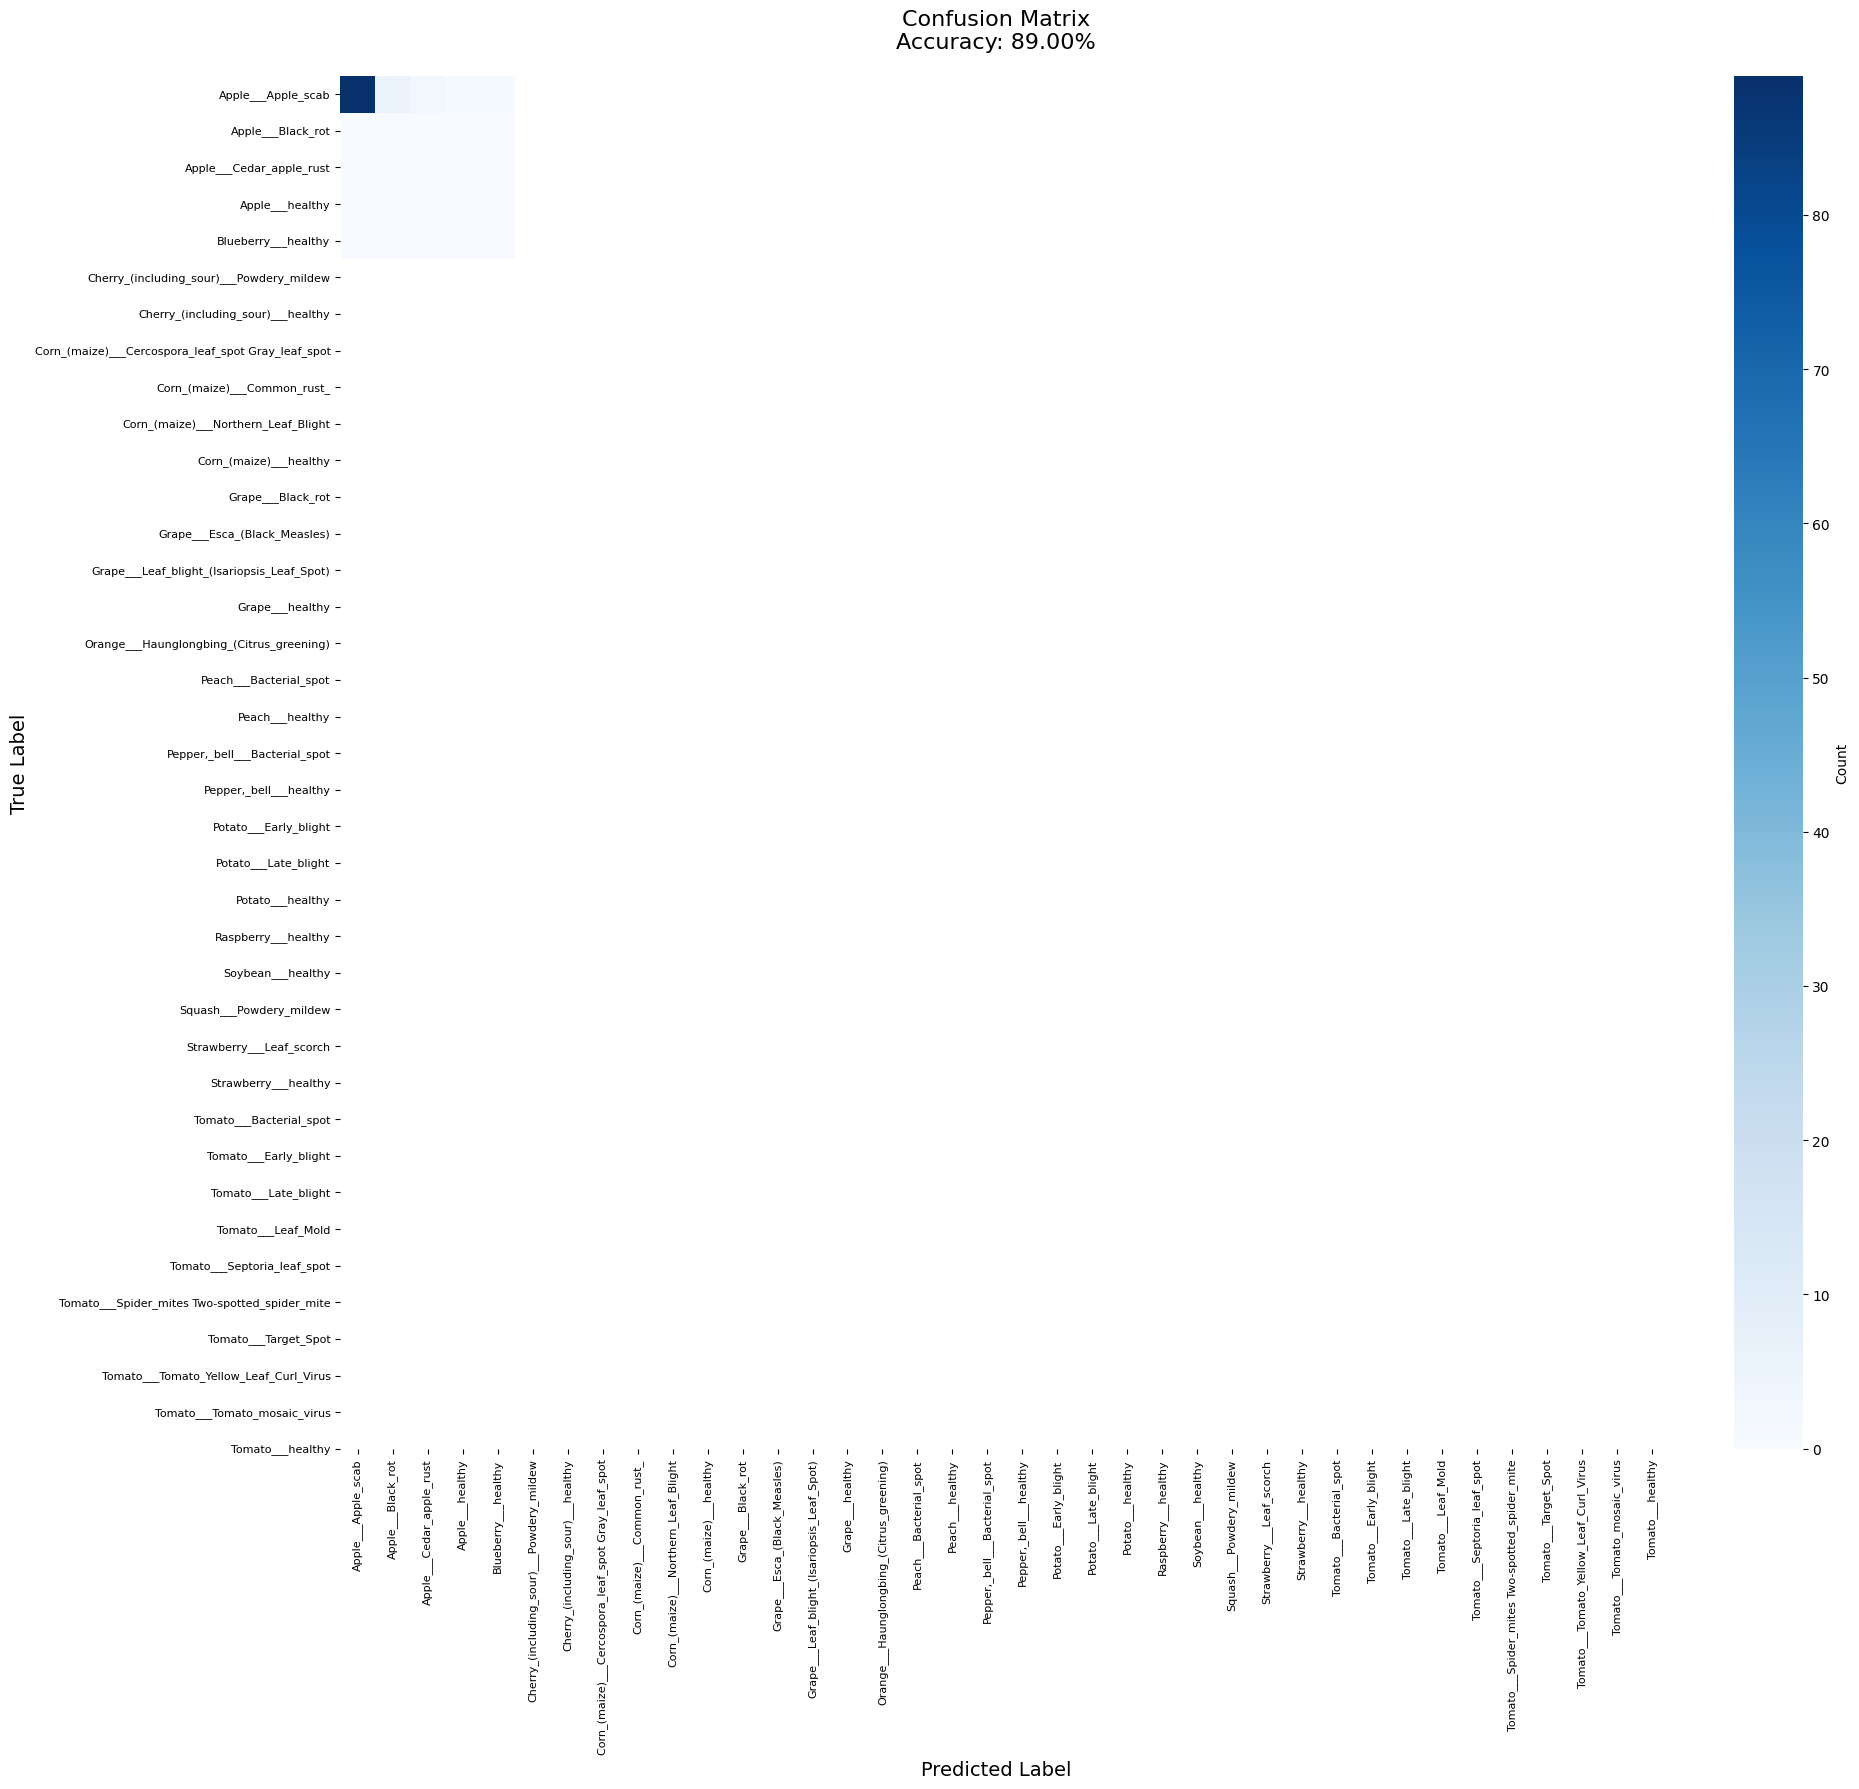


──────────────────────────────────────────────────────────────────────
STEP 5: Error Analysis
──────────────────────────────────────────────────────────────────────

🔍 Analyzing per-class performance...

🏆 TOP 5 BEST PERFORMING CLASSES
1. Apple___Apple_scab
   Accuracy: 89.00% | Samples: 100 | Errors: 11

⚠️ TOP 5 WORST PERFORMING CLASSES
1. Apple___Apple_scab
   Accuracy: 89.00% | Samples: 100 | Errors: 11

──────────────────────────────────────────────────────────────────────
STEP 6: Sample Visualizations
──────────────────────────────────────────────────────────────────────

📸 Showing random predictions...
✅ Saved: sample_predictions_random.png


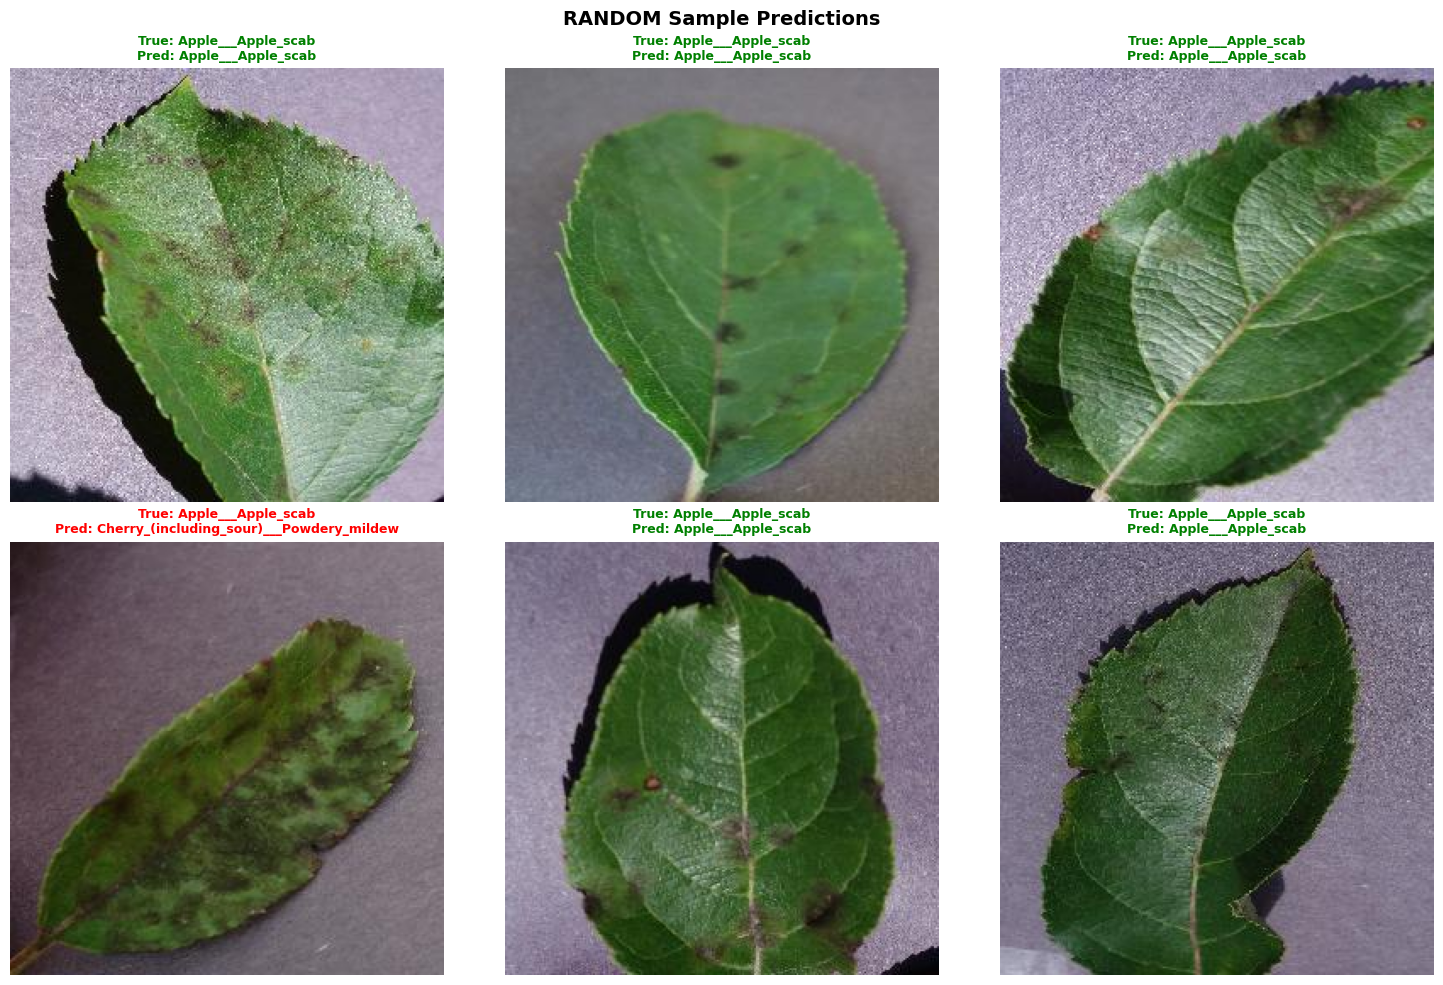


📸 Showing misclassified examples...
✅ Saved: sample_predictions_errors.png


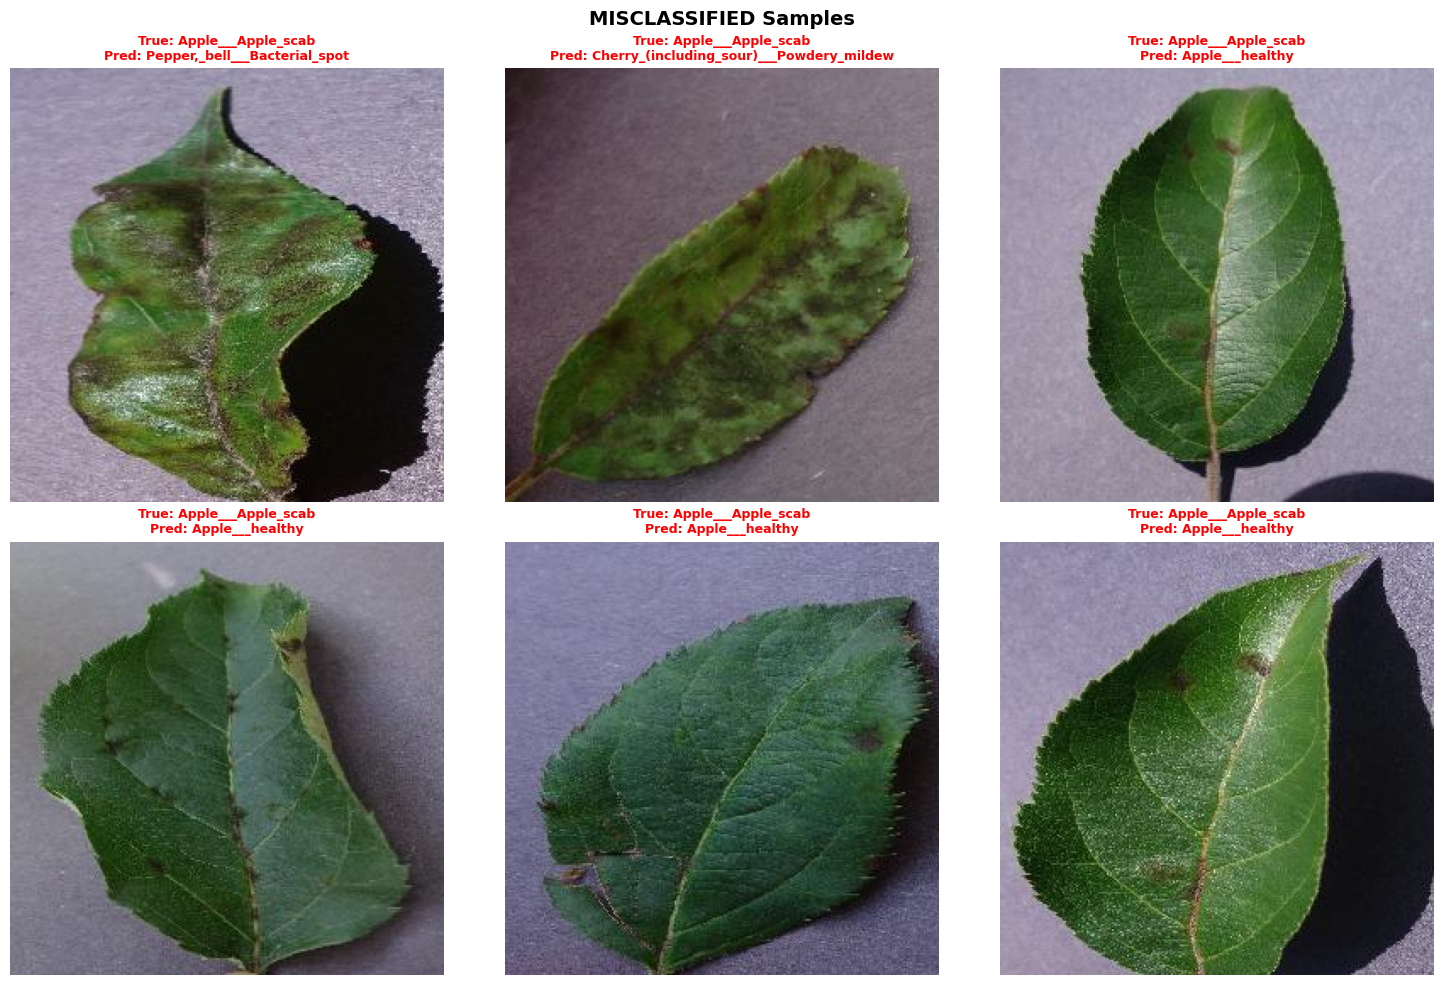


✅ EVALUATION COMPLETE!

📁 Generated Files:
   • confusion_matrix_evaluation.png
   • sample_predictions_random.png
   • sample_predictions_errors.png

🌐 Benefits of using public Drive links:
   ✅ No need to mount Google Drive
   ✅ Anyone can run this notebook with these links
   ✅ Dataset downloads directly to Colab


In [30]:
print('\n## Run Complete Model Evaluation')
print('='*70)

# Create evaluator with your existing classifier
print('\n🚀 Starting evaluation process...')

evaluator = PlantDiseaseEvaluator(image_classifier)

# ============================================================================
# DOWNLOAD FROM PUBLIC GOOGLE DRIVE LINKS
# ============================================================================

print('\n📥 Downloading dataset from public Google Drive links...')
print('This will create the dataset folder locally in Colab')

import os
import gdown

# Create dataset directory
dataset_path = '/content/plant_disease_dataset'
os.makedirs(dataset_path, exist_ok=True)

print(f'\n📂 Creating dataset folder: {dataset_path}')

try:
    # Download state.json
    print('\n1️⃣ Downloading state.json...')
    gdown.download(
        'https://drive.google.com/uc?id=17QHF92X7GyOu2LmU4Xx4FxJsJMuTz7L-',
        f'{dataset_path}/state.json',
        quiet=False
    )

    # Download dataset_info.json
    print('\n2️⃣ Downloading dataset_info.json...')
    gdown.download(
        'https://drive.google.com/uc?id=1NMNwS9596vgge4uz8GAYZ6TZWKzGBUE4',
        f'{dataset_path}/dataset_info.json',
        quiet=False
    )

    # Download data file (this is the big one - ~170 MB)
    print('\n3️⃣ Downloading data-00000-of-00001.arrow (~170 MB)...')
    print('⏱️ This may take 1-2 minutes...')
    gdown.download(
        'https://drive.google.com/uc?id=15KRqFToF3abWTy6plJTcHs9GDoUSxNSI',
        f'{dataset_path}/data-00000-of-00001.arrow',
        quiet=False
    )

    print('\n✅ All files downloaded successfully!')
    print(f'📁 Dataset location: {dataset_path}')

    # Verify files
    print('\n🔍 Verifying downloaded files...')
    required_files = ['state.json', 'dataset_info.json', 'data-00000-of-00001.arrow']
    for file in required_files:
        file_path = f'{dataset_path}/{file}'
        if os.path.exists(file_path):
            size_mb = os.path.getsize(file_path) / (1024 * 1024)
            print(f'   ✅ {file} ({size_mb:.2f} MB)')
        else:
            print(f'   ❌ {file} - MISSING!')

    # Load the dataset from local path
    print('\n📥 Loading dataset from downloaded files...')
    from datasets import load_from_disk

    evaluator.test_dataset = load_from_disk(dataset_path)
    evaluator.label_names = evaluator.test_dataset.features['label'].names

    print('\n✅ Dataset loaded successfully!')
    print(f'   - Test samples: {len(evaluator.test_dataset):,}')
    print(f'   - Classes: {len(evaluator.label_names)}')
    print(f'   - Source: Public Google Drive links')

except Exception as e:
    print(f'\n❌ Error downloading or loading dataset: {e}')
    print('\n💡 Troubleshooting:')
    print('   1. Check your internet connection')
    print('   2. Verify the Google Drive links are public')
    print('   3. Make sure gdown is installed: !pip install gdown')

# ============================================================================
# EVALUATION
# ============================================================================

if evaluator.test_dataset is not None:

    # Step 2: Evaluate model
    print('\n' + '─'*70)
    print('STEP 2: Evaluating Model')
    print('─'*70)

    # 💡 TIP: Change max_samples for faster testing
    # max_samples=100   → Quick test (3 minutes)
    # max_samples=None  → Full evaluation (8 minutes)

    results = evaluator.evaluate_model(
        max_samples=100,  # Change to 100 for quick test
        batch_display=500
    )

    if results:
        # Step 3: Display metrics
        print('\n' + '─'*70)
        print('STEP 3: Results Summary')
        print('─'*70)
        evaluator.display_metrics()

        # Step 4: Confusion matrix
        print('\n' + '─'*70)
        print('STEP 4: Confusion Matrix')
        print('─'*70)
        evaluator.create_confusion_matrix()

        # Step 5: Error analysis
        print('\n' + '─'*70)
        print('STEP 5: Error Analysis')
        print('─'*70)
        evaluator.analyze_errors(top_n=5)

        # Step 6: Sample visualizations
        print('\n' + '─'*70)
        print('STEP 6: Sample Visualizations')
        print('─'*70)

        print('\n📸 Showing random predictions...')
        evaluator.visualize_sample_predictions(num_samples=6, show_errors=False)

        print('\n📸 Showing misclassified examples...')
        evaluator.visualize_sample_predictions(num_samples=6, show_errors=True)

        print('\n' + '='*70)
        print('✅ EVALUATION COMPLETE!')
        print('='*70)
        print('\n📁 Generated Files:')
        print('   • confusion_matrix_evaluation.png')
        print('   • sample_predictions_random.png')
        print('   • sample_predictions_errors.png')

        print('\n🌐 Benefits of using public Drive links:')
        print('   ✅ No need to mount Google Drive')
        print('   ✅ Anyone can run this notebook with these links')
        print('   ✅ Dataset downloads directly to Colab')

else:
    print('\n❌ Dataset not loaded. Cannot proceed with evaluation.')

In [ ]:
def show_evaluation_summary():
    """Quick function to redisplay results."""
    if 'evaluator' in globals() and evaluator.results:
        evaluator.display_metrics()
    else:
        print('❌ Run evaluation first!')

def show_confusion_matrix():
    """Redisplay confusion matrix."""
    if 'evaluator' in globals() and evaluator.results:
        evaluator.create_confusion_matrix()
    else:
        print('❌ Run evaluation first!')

def show_error_analysis():
    """Redisplay error analysis."""
    if 'evaluator' in globals() and evaluator.results:
        evaluator.analyze_errors(top_n=5)
    else:
        print('❌ Run evaluation first!')

print('✅ Helper functions ready!')
print('\nQuick commands:')
print('  • show_evaluation_summary()')
print('  • show_confusion_matrix()')
print('  • show_error_analysis()')

## 15. Automated Report Generator 📄

In [ ]:
class AutomatedReportGenerator:
    """
    Generate professional reports using Hugging Face LLMs.
    Creates daily/weekly summaries with insights.
    """

    def __init__(self, cerebras_client: Cerebras, model_name: str):
        self.client = cerebras_client
        self.model_name = model_name

    def generate_daily_report(self, df: pd.DataFrame, alerts: List[Dict],
                            probabilities: Dict, weather: Dict = None) -> str:
        """Generate daily summary report."""
        if df.empty:
            return "No data available for report."

        # Get last 24 hours
        cutoff = df['timestamp'].max() - timedelta(hours=24)
        daily = df[df['timestamp'] > cutoff]

        if daily.empty:
            daily = df.tail(100)  # Use last 100 readings

        # Statistics
        stats = {
            'date': daily['timestamp'].max().strftime('%Y-%m-%d'),
            'readings': len(daily),
            'temp_avg': daily['temperature'].mean(),
            'temp_min': daily['temperature'].min(),
            'temp_max': daily['temperature'].max(),
            'humidity_avg': daily['humidity'].mean(),
            'humidity_min': daily['humidity'].min(),
            'humidity_max': daily['humidity'].max(),
            'soil_avg': daily['soil'].mean(),
            'soil_min': daily['soil'].min(),
            'soil_max': daily['soil'].max()
        }

        # Build prompt for AI summary
        prompt = f"""Generate a professional daily plant health report based on this data:

DATE: {stats['date']}
READINGS: {stats['readings']} sensor measurements

ENVIRONMENTAL CONDITIONS:
- Temperature: {stats['temp_avg']:.1f}°C (range: {stats['temp_min']:.1f}-{stats['temp_max']:.1f}°C)
- Humidity: {stats['humidity_avg']:.1f}% (range: {stats['humidity_min']:.1f}-{stats['humidity_max']:.1f}%)
- Soil Moisture: {stats['soil_avg']:.1f}% (range: {stats['soil_min']:.1f}-{stats['soil_max']:.1f}%)

ALERTS: {len(alerts)} active alerts
TOP DISEASE RISK: {probabilities['top_risk']['disease']} ({probabilities['top_risk']['probability']:.1f}%)

Generate a concise daily summary (3-4 paragraphs) covering:
1. Overall environmental conditions
2. Disease risks and recommendations
3. Action items for tomorrow
"""

        try:
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=[
                    {"role": "system", "content": "You are an agricultural consultant generating daily plant health reports."},
                    {"role": "user", "content": prompt}
                ],
                temperature=0.3,
                max_tokens=1000
            )

            summary = response.choices[0].message.content
            summary = re.sub(r'<think>.*?</think>', '', summary, flags=re.DOTALL)

            return summary
        except Exception as e:
            return f"Error generating report: {str(e)}"

    def create_docx_report(self, df: pd.DataFrame, alerts: List[Dict],
                          probabilities: Dict, output_path: str = "daily_report.docx") -> str:
        """Create formatted Word document report."""
        doc = Document()

        # Title
        title = doc.add_heading('🌱 Daily Plant Health Report', 0)
        title.alignment = WD_ALIGN_PARAGRAPH.CENTER

        # Date
        date_para = doc.add_paragraph()
        date_para.add_run(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n").bold = True
        date_para.alignment = WD_ALIGN_PARAGRAPH.CENTER

        # Executive Summary
        doc.add_heading('Executive Summary', 1)
        ai_summary = self.generate_daily_report(df, alerts, probabilities)
        doc.add_paragraph(ai_summary)

        # Environmental Conditions
        doc.add_heading('Environmental Conditions', 1)

        if not df.empty:
            daily = df.tail(100)

            table = doc.add_table(rows=4, cols=4)
            table.style = 'Light Grid Accent 1'

            headers = table.rows[0].cells
            headers[0].text = 'Parameter'
            headers[1].text = 'Current'
            headers[2].text = 'Average'
            headers[3].text = 'Range'

            # Temperature
            row1 = table.rows[1].cells
            row1[0].text = '🌡️ Temperature'
            row1[1].text = f"{daily['temperature'].iloc[-1]:.1f}°C"
            row1[2].text = f"{daily['temperature'].mean():.1f}°C"
            row1[3].text = f"{daily['temperature'].min():.1f}-{daily['temperature'].max():.1f}°C"

            # Humidity
            row2 = table.rows[2].cells
            row2[0].text = '💧 Humidity'
            row2[1].text = f"{daily['humidity'].iloc[-1]:.1f}%"
            row2[2].text = f"{daily['humidity'].mean():.1f}%"
            row2[3].text = f"{daily['humidity'].min():.1f}-{daily['humidity'].max():.1f}%"

            # Soil
            row3 = table.rows[3].cells
            row3[0].text = '🌱 Soil Moisture'
            row3[1].text = f"{daily['soil'].iloc[-1]:.1f}%"
            row3[2].text = f"{daily['soil'].mean():.1f}%"
            row3[3].text = f"{daily['soil'].min():.1f}-{daily['soil'].max():.1f}%"

        # Alerts
        doc.add_heading('Active Alerts', 1)
        if alerts:
            for alert in alerts:
                p = doc.add_paragraph(style='List Bullet')
                p.add_run(f"{alert['level']}: ").bold = True
                p.add_run(alert['message'])
        else:
            doc.add_paragraph("✅ No alerts - All conditions normal")

        # Disease Probabilities
        doc.add_heading('Disease Risk Assessment', 1)
        for disease_type, data in probabilities['sorted']:
            p = doc.add_paragraph()
            p.add_run(f"{data['disease']}: ").bold = True
            p.add_run(f"{data['probability']}% {data['risk_level']}")

        # Save
        doc.save(output_path)
        print(f"✓ Report saved: {output_path}")
        return output_path

# Initialize report generator
report_gen = AutomatedReportGenerator(client, MODEL_NAME)
print("✓ Report generator initialized")

# Generate sample report

print('✅ AutomatedReportGenerator class defined')


## 16. RAG System Components 📚

## 16. RAG System Components 📚
### Document Indexer & Helper Functions

In [ ]:
"""
🌟 ULTIMATE PLANT DISEASE INDEXER - INTEGRATED VERSION
=======================================================
Features:
✅ Phase 1: Proper TF-IDF with stemming and normalization
✅ Phase 2: Semantic embeddings (SentenceTransformer)
✅ Hybrid search combining keyword + semantic
✅ Passage-level retrieval (fixes Wikipedia length bias naturally)
✅ BM25 algorithm (industry standard)
✅ No artificial weights - pure algorithm quality
"""

import re
import math
import numpy as np
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
from dataclasses import dataclass
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize

# ============================================================================
# DATA STRUCTURES
# ============================================================================

@dataclass
class SearchResult:
    """Structured search result."""
    doc_id: str
    passage_id: Optional[str]
    score: float
    title: str
    text: str
    doi: str
    source_type: str
    keyword_score: float
    semantic_score: float

    def to_dict(self):
        return {
            'doc_id': self.doc_id,
            'passage_id': self.passage_id,
            'score': self.score,
            'title': self.title,
            'text': self.text[:500] + '...' if len(self.text) > 500 else self.text,
            'doi': self.doi,
            'source_type': self.source_type,
            'keyword_score': self.keyword_score,
            'semantic_score': self.semantic_score
        }

# ============================================================================
# PASSAGE SPLITTER
# ============================================================================

class PassageSplitter:
    """Split documents into passages for better retrieval."""

    def __init__(self, max_passage_length: int = 500, overlap: int = 50):
        self.max_passage_length = max_passage_length
        self.overlap = overlap

    def split_by_paragraphs(self, text: str) -> List[str]:
        """Split into paragraphs, then chunk if too long."""
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()]

        passages = []
        for para in paragraphs:
            if len(para) <= self.max_passage_length:
                passages.append(para)
            else:
                sentences = sent_tokenize(para)
                current_passage = ""

                for sent in sentences:
                    if len(current_passage) + len(sent) <= self.max_passage_length:
                        current_passage += sent + " "
                    else:
                        if current_passage:
                            passages.append(current_passage.strip())
                        current_passage = sent + " "

                if current_passage:
                    passages.append(current_passage.strip())

        return passages

# ============================================================================
# IMPROVED TOKENIZER
# ============================================================================

class ImprovedTokenizer:
    """Tokenizer with stemming and better handling of scientific terms."""

    def __init__(self):
        self.stemmer = PorterStemmer()
        self.stop_words = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
            'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
            'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
            'could', 'should', 'may', 'might', 'can', 'this', 'that', 'these',
            'those', 'it', 'its', 'they', 'them', 'their', 'what', 'which',
            'who', 'when', 'where', 'why', 'how', 'all', 'each', 'every',
            'both', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor',
            'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just'
        }

    def tokenize(self, text: str, apply_stemming: bool = True) -> List[str]:
        """Tokenize text with proper handling of scientific terms."""
        tokens = re.findall(r'\b[a-zA-Z][a-zA-Z0-9_-]*\b', text.lower())

        processed = []
        for token in tokens:
            if token in self.stop_words or len(token) < 2:
                continue

            if apply_stemming:
                token = self.stemmer.stem(token)

            processed.append(token)

        return processed

# ============================================================================
# ADVANCED TF-IDF INDEXER
# ============================================================================

class AdvancedTFIDFIndexer:
    """Improved TF-IDF indexer with BM25 and passage-level indexing."""

    def __init__(self, use_bm25: bool = True):
        self.use_bm25 = use_bm25
        self.tokenizer = ImprovedTokenizer()
        self.splitter = PassageSplitter(max_passage_length=500, overlap=50)

        # Storage
        self.inverted_index = defaultdict(lambda: defaultdict(list))
        self.passages = {}
        self.documents = {}

        # Statistics
        self.doc_count = 0
        self.passage_count = 0
        self.avg_passage_length = 0
        self.total_passage_length = 0

        # BM25 parameters
        self.k1 = 1.5
        self.b = 0.75

    def add_document(self, doc_id: str, text: str, metadata: Dict = None):
        """Add document with passage-level indexing."""
        # Split into passages
        passages = self.splitter.split_by_paragraphs(text)

        if not passages:
            passages = [text]

        # Store document info
        self.documents[doc_id] = {
            'metadata': metadata or {},
            'passage_ids': []
        }

        # Index each passage
        for i, passage_text in enumerate(passages):
            passage_id = f"{doc_id}_p{i}"

            # Tokenize
            tokens = self.tokenizer.tokenize(passage_text)

            if not tokens:
                continue

            # Store passage
            self.passages[passage_id] = {
                'doc_id': doc_id,
                'text': passage_text,
                'tokens': tokens,
                'length': len(tokens)
            }

            # Build inverted index
            for pos, term in enumerate(tokens):
                self.inverted_index[term][passage_id].append(pos)

            # Update statistics
            self.documents[doc_id]['passage_ids'].append(passage_id)
            self.passage_count += 1
            self.total_passage_length += len(tokens)

        self.doc_count += 1
        self.avg_passage_length = self.total_passage_length / self.passage_count if self.passage_count > 0 else 0

    def _calculate_bm25_score(self, passage_id: str, query_terms: List[str]) -> float:
        """Calculate BM25 score for a passage."""
        if passage_id not in self.passages:
            return 0.0

        passage_data = self.passages[passage_id]
        passage_length = passage_data['length']

        score = 0.0
        for term in query_terms:
            if term not in self.inverted_index:
                continue

            # Term frequency in passage
            tf = len(self.inverted_index[term].get(passage_id, []))

            # Document frequency
            df = len(self.inverted_index[term])

            # IDF
            idf = math.log((self.passage_count - df + 0.5) / (df + 0.5) + 1.0)

            # Length normalization
            length_norm = (passage_length / self.avg_passage_length) if self.avg_passage_length > 0 else 1.0

            # BM25 formula
            numerator = tf * (self.k1 + 1)
            denominator = tf + self.k1 * (1 - self.b + self.b * length_norm)

            score += idf * (numerator / denominator)

        return score

    def _calculate_tfidf_score(self, passage_id: str, query_terms: List[str]) -> float:
        """Calculate TF-IDF score for a passage."""
        if passage_id not in self.passages:
            return 0.0

        passage_data = self.passages[passage_id]
        passage_length = passage_data['length']

        if passage_length == 0:
            return 0.0

        score = 0.0
        for term in query_terms:
            if term not in self.inverted_index:
                continue

            # TF (normalized by passage length)
            tf = len(self.inverted_index[term].get(passage_id, [])) / passage_length

            # IDF
            df = len(self.inverted_index[term])
            idf = math.log(self.passage_count / df) if df > 0 else 0

            score += tf * idf

        return score

    def search(self, query: str, top_k: int = 10) -> List[Tuple[str, str, float]]:
        """Search passages and return (doc_id, passage_id, score)."""
        query_terms = self.tokenizer.tokenize(query)

        if not query_terms:
            return []

        # Score all passages
        passage_scores = {}
        for passage_id in self.passages:
            if self.use_bm25:
                score = self._calculate_bm25_score(passage_id, query_terms)
            else:
                score = self._calculate_tfidf_score(passage_id, query_terms)

            if score > 0:
                doc_id = self.passages[passage_id]['doc_id']
                passage_scores[passage_id] = (doc_id, score)

        # Sort and return top k
        ranked = sorted(passage_scores.items(), key=lambda x: x[1][1], reverse=True)

        return [(doc_id, passage_id, score) for passage_id, (doc_id, score) in ranked[:top_k]]

# ============================================================================
# SEMANTIC ENGINE (Optional)
# ============================================================================

try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    SEMANTIC_AVAILABLE = True
except ImportError:
    SEMANTIC_AVAILABLE = False

class SemanticEngine:
    """Semantic search using sentence transformers."""

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self.available = SEMANTIC_AVAILABLE
        self.model = None
        self.passage_embeddings = {}

        if SEMANTIC_AVAILABLE:
            try:
                print(f"Loading semantic model: {model_name}...")
                self.model = SentenceTransformer(model_name)
                print("✓ Semantic model loaded")
            except Exception as e:
                print(f"⚠️ Could not load semantic model: {e}")
                self.available = False

    def encode_passages(self, passages: Dict):
        """Encode all passages."""
        if not self.available or not self.model:
            return

        print(f"Encoding {len(passages)} passages...")
        texts = [p['text'] for p in passages.values()]
        passage_ids = list(passages.keys())

        try:
            embeddings = self.model.encode(texts, show_progress_bar=True)
            self.passage_embeddings = dict(zip(passage_ids, embeddings))
            print("✓ Passages encoded")
        except Exception as e:
            print(f"⚠️ Error encoding passages: {e}")
            self.available = False

    def search(self, query: str, top_k: int = 10) -> List[Tuple[str, str, float]]:
        """Semantic search returning (doc_id, passage_id, score)."""
        if not self.available or not self.model or not self.passage_embeddings:
            return []

        try:
            # Encode query
            query_embedding = self.model.encode([query])[0]

            # Calculate similarities
            scores = {}
            for passage_id, passage_emb in self.passage_embeddings.items():
                similarity = cosine_similarity([query_embedding], [passage_emb])[0][0]
                scores[passage_id] = similarity

            # Sort and return
            ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

            # Get doc_ids (we'll need to access passage data from the indexer)
            # For now, just return passage_id and score
            return [(passage_id.split('_p')[0], passage_id, score) for passage_id, score in ranked[:top_k]]

        except Exception as e:
            print(f"⚠️ Semantic search error: {e}")
            return []

# ============================================================================
# ULTIMATE SEARCH SYSTEM
# ============================================================================

class UltimatePlantDiseaseSearch:
    """Complete hybrid search system."""

    def __init__(self, use_semantic: bool = True):
        self.keyword_indexer = AdvancedTFIDFIndexer(use_bm25=True)
        self.semantic_engine = SemanticEngine() if use_semantic and SEMANTIC_AVAILABLE else None
        self.documents_meta = {}

    def add_document(self, doc_id: str, text: str, metadata: Dict = None):
        """Add document to both indexers."""
        self.keyword_indexer.add_document(doc_id, text, metadata)
        self.documents_meta[doc_id] = metadata or {}

    def build_index(self):
        """Build semantic index after all documents added."""
        if self.semantic_engine and self.semantic_engine.available:
            print("\n🧠 Building semantic index...")
            self.semantic_engine.encode_passages(self.keyword_indexer.passages)

    def search(self, query: str, top_k: int = 5, semantic_weight: float = 0.6,
               return_passages: bool = True) -> List[SearchResult]:
        """
        Hybrid search combining keyword and semantic.

        Args:
            query: Search query
            top_k: Number of results to return
            semantic_weight: Weight for semantic vs keyword (0.0 to 1.0)
            return_passages: If True, return passages; if False, aggregate to documents
        """
        # === 1. KEYWORD SEARCH (BM25/TF-IDF) ===
        keyword_results = self.keyword_indexer.search(query, top_k=top_k * 3)

        # Normalize scores to 0-1
        keyword_scores = {}
        if keyword_results:
            max_score = max(score for _, _, score in keyword_results)
            if max_score > 0:
                for doc_id, passage_id, score in keyword_results:
                    keyword_scores[passage_id] = score / max_score

        # === 2. SEMANTIC SEARCH ===
        semantic_scores = {}
        if self.semantic_engine and self.semantic_engine.available:
            semantic_results = self.semantic_engine.search(query, top_k=top_k * 3)

            for doc_id, passage_id, score in semantic_results:
                semantic_scores[passage_id] = score

        # === 3. COMBINE SCORES ===
        all_passages = set(keyword_scores.keys()) | set(semantic_scores.keys())

        combined_scores = {}
        for passage_id in all_passages:
            keyword_score = keyword_scores.get(passage_id, 0.0)
            semantic_score = semantic_scores.get(passage_id, 0.0)

            if self.semantic_engine and self.semantic_engine.available:
                combined = (1 - semantic_weight) * keyword_score + semantic_weight * semantic_score
            else:
                combined = keyword_score

            combined_scores[passage_id] = combined

        # === 4. RANK AND FORMAT ===
        ranked_passages = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

        # Convert to SearchResult objects
        results = []
        seen_docs = set()

        for passage_id, score in ranked_passages:
            passage_data = self.keyword_indexer.passages[passage_id]
            doc_id = passage_data['doc_id']

            # If not returning passages, skip duplicate documents
            if not return_passages and doc_id in seen_docs:
                continue

            metadata = self.documents_meta.get(doc_id, {})

            result = SearchResult(
                doc_id=doc_id,
                passage_id=passage_id if return_passages else None,
                score=score,
                title=metadata.get('title', doc_id),
                text=passage_data['text'],
                doi=metadata.get('doi', 'N/A'),
                source_type=metadata.get('type', 'unknown'),
                keyword_score=keyword_scores.get(passage_id, 0.0),
                semantic_score=semantic_scores.get(passage_id, 0.0)
            )

            results.append(result)
            seen_docs.add(doc_id)

            if len(results) >= top_k:
                break

        return results

    def get_stats(self) -> Dict:
        """Get system statistics."""
        return {
            'total_documents': self.keyword_indexer.doc_count,
            'total_passages': self.keyword_indexer.passage_count,
            'avg_passage_length': self.keyword_indexer.avg_passage_length,
            'unique_terms': len(self.keyword_indexer.inverted_index),
            'semantic_enabled': self.semantic_engine is not None and self.semantic_engine.available,
            'bm25_enabled': self.keyword_indexer.use_bm25
        }

print("✓ Advanced indexer components loaded")



In [ ]:
class PlantDiseaseRAG:
    """
    🔒 STRICT RAG - Only uses indexed PDFs and sensor data.
    Will NOT use general AI knowledge or search internet.
    """

    def __init__(self, indexer, cerebras_client, model_name):
        self.indexer = indexer
        self.client = cerebras_client
        self.model_name = model_name
        print("🔒 RAG initialized in STRICT mode - only indexed papers!")

    def _build_context(self, search_results):
        """Build context from indexed documents."""
        context_parts = []
        for i, result in enumerate(search_results, 1):
            if isinstance(result, SearchResult):
                # New advanced indexer returns SearchResult objects
                text_snippet = result.text[:2000] if len(result.text) > 2000 else result.text
                context_parts.append(f"""
═══ PAPER {i} ═══
Title: {result.title}
DOI: {result.doi}
Relevance: {result.score:.3f}

Content:
{text_snippet}
{'...(truncated)' if len(result.text) > 2000 else ''}
""")
            else:
                # Fallback for old format (doc_id, score)
                doc_id, score = result
                doc_text = ''
                metadata = {}

                # Try to get document text
                if hasattr(self.indexer, 'keyword_indexer'):
                    # New indexer structure
                    if hasattr(self.indexer.keyword_indexer, 'documents'):
                        doc_info = self.indexer.keyword_indexer.documents.get(doc_id, {})
                        # Get first passage text as fallback
                        if 'passage_ids' in doc_info and doc_info['passage_ids']:
                            first_passage_id = doc_info['passage_ids'][0]
                            passage_data = self.indexer.keyword_indexer.passages.get(first_passage_id, {})
                            doc_text = passage_data.get('text', '')

                    # Get metadata
                    if hasattr(self.indexer, 'documents_meta'):
                        metadata = self.indexer.documents_meta.get(doc_id, {})

                text_snippet = doc_text[:2000] if len(doc_text) > 2000 else doc_text

                context_parts.append(f"""
═══ PAPER {i} ═══
Title: {metadata.get('title', doc_id)}
DOI: {metadata.get('doi', 'N/A')}
Relevance: {score:.3f}

Content:
{text_snippet}
{'...(truncated)' if len(doc_text) > 2000 else ''}
""")

        return "\n".join(context_parts)

    def _build_strict_prompt(self, query, context, iot_data=None):
        """Build prompt that ENFORCES using only provided papers."""

        system_rules = """🔒 CRITICAL INSTRUCTIONS - YOU MUST OBEY:

1. ✅ Answer ONLY from the provided knowledge sources (research papers and Wikipedia articles).
2. ❌ DO NOT use your general training knowledge.
3. ❌ DO NOT search the internet.
4. ❌ DO NOT make assumptions beyond the provided sources.
5. ❌ DO NOT invent or hallucinate information.
6. ✅ If information is NOT found in the provided sources, respond: "This information is not found in the indexed research papers or Wikipedia articles."
7. ✅ ALWAYS cite which source you're referencing (e.g., "According to Paper 2...")
8. ✅ Be honest about limitations.

You are a research assistant with access to ONLY the provided indexed documents. Nothing else."""

        prompt = f"""{system_rules}

═══════════════════════════════════════════════════════════
📚 YOUR ONLY KNOWLEDGE SOURCE (Research Papers & Wikipedia Articles):
═══════════════════════════════════════════════════════════

{context}

═══════════════════════════════════════════════════════════
"""

        if iot_data:
            prompt += f"""
📊 CURRENT SENSOR DATA (Real-time from Firebase):
═══════════════════════════════════════════════════════════
Temperature: {iot_data.get('temperature', 'N/A'):.1f}°C
Humidity: {iot_data.get('humidity', 'N/A'):.1f}%
Soil Moisture: {iot_data.get('soil', 'N/A'):.1f}%
Risk Level: {iot_data.get('risk_level', 'Unknown')}
Top Risk: {iot_data.get('top_disease', 'Unknown')}
═══════════════════════════════════════════════════════════

NOTE: You CAN reference this real-time sensor data in your answer.

"""

        prompt += f"""
❓ QUESTION: {query}

📑 REQUIRED RESPONSE FORMAT:
1. Search ONLY the research papers and Wikipedia articles above
2. If answer found: Provide answer + cite source (e.g., "According to Paper 2, ..." or "Wikipedia (Plant Pathology) states...")
3. If answer NOT found: Say "This information is not found in the indexed research papers or Wikipedia articles."
4. You MAY combine source info with sensor data if relevant
5. Be completely honest - don't make things up

✍️ YOUR ANSWER (follow the rules above):"""

        return prompt

    def _extract_sources(self, search_results):
        """Extract clean source information."""
        sources = []
        for result in search_results:
            if isinstance(result, SearchResult):
                # New advanced indexer returns SearchResult objects
                sources.append({
                    'paper': result.title,
                    'doi': result.doi if result.doi != 'N/A' else 'Not available',
                    'doi_link': f"https://doi.org/{result.doi}" if result.doi != 'N/A' else None,
                    'relevance_score': f"{result.score:.3f}",
                    'passage_id': result.passage_id if hasattr(result, 'passage_id') and result.passage_id else None
                })
            else:
                # Fallback for old format
                doc_id, score = result if isinstance(result, tuple) else (result, 0.0)
                metadata = {}

                if hasattr(self.indexer, 'documents_meta'):
                    metadata = self.indexer.documents_meta.get(doc_id, {})

                sources.append({
                    'paper': metadata.get('title', doc_id),
                    'doi': metadata.get('doi', 'Not available'),
                    'doi_link': f"https://doi.org/{metadata.get('doi', '')}" if metadata.get('doi') and metadata.get('doi') != 'N/A' else None,
                    'relevance_score': f"{score:.3f}"
                })
        return sources

    def generate_enriched_response(self, query, iot_data=None, top_k=7, temperature=0.1):
        """
        Generate response STRICTLY from indexed papers + optional sensor data.

        Args:
            query (str): User question
            iot_data (dict): Optional current sensor readings
            top_k (int): Number of papers to search (1-10)
            temperature (float): 0.1 = very strict, 0.7 = more creative

        Returns:
            dict: Response with answer, sources, and metadata
        """

        # Search ONLY the indexed documents
        search_results = self.indexer.search(query, top_k=top_k, return_passages=True)

        if not search_results:
            # Get document count
            doc_count = 0
            if hasattr(self.indexer, 'keyword_indexer'):
                doc_count = self.indexer.keyword_indexer.doc_count
            elif hasattr(self.indexer, 'doc_count'):
                doc_count = self.indexer.doc_count

            return {
                'answer': '❌ **No Relevant Information Found**\n\nYour question did not match content in any of the indexed research papers or Wikipedia articles.\n\n**Suggestions:**\n- Rephrase your question\n- Ask about topics covered in the papers (plant disease detection, CNN, image segmentation, etc.)',
                'sources': [],
                'context_found': False,
                'papers_searched': doc_count,
                'papers_used': 0
            }

        # Build context from found papers
        context = self._build_context(search_results)

        # Build STRICT prompt
        prompt = self._build_strict_prompt(query, context, iot_data)

        try:
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=[
                    {
                        "role": "system",
                        "content": "You are a research assistant. You can ONLY answer from the provided knowledge sources. If information is not in the sources, you MUST say so explicitly. Do not use your general knowledge."
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ],
                temperature=temperature,
                max_tokens=800
            )

            answer = response.choices[0].message.content
            sources = self._extract_sources(search_results)

            # Get document count
            doc_count = 0
            if hasattr(self.indexer, 'keyword_indexer'):
                doc_count = self.indexer.keyword_indexer.doc_count
            elif hasattr(self.indexer, 'doc_count'):
                doc_count = self.indexer.doc_count

            footer = f"\n\n---\n📊 **Search Stats:** Searched {doc_count} sources, found {len(search_results)} relevant"

            return {
                'answer': answer + footer,
                'sources': sources,
                'context_found': True,
                'papers_searched': doc_count,
                'papers_used': len(search_results)
            }

        except Exception as e:
            # Get document count
            doc_count = 0
            if hasattr(self.indexer, 'keyword_indexer'):
                doc_count = self.indexer.keyword_indexer.doc_count
            elif hasattr(self.indexer, 'doc_count'):
                doc_count = self.indexer.doc_count

            return {
                'answer': f'❌ **Error:** {str(e)}\n\nCould not generate response from sources.',
                'sources': [],
                'context_found': False,
                'papers_searched': doc_count,
                'papers_used': 0
            }

    def list_available_papers(self):
        """List all indexed papers for user reference."""
        doc_metadata = None

        # Try to get metadata from different indexer structures
        if hasattr(self.indexer, 'documents_meta'):
            doc_metadata = self.indexer.documents_meta
        elif hasattr(self.indexer, 'doc_metadata'):
            doc_metadata = self.indexer.doc_metadata

        if not doc_metadata:
            return "No papers indexed yet."

        papers_list = ["📚 **Available Research Papers & Wikipedia Articles:**\n"]
        for i, (doc_id, metadata) in enumerate(doc_metadata.items(), 1):
            papers_list.append(f"{i}. **{metadata.get('title', doc_id)}**")
            papers_list.append(f"   DOI: {metadata.get('doi', 'N/A')}\n")

        return "\n".join(papers_list)

print("✓ Fixed PlantDiseaseRAG class loaded")


## 17. Load Research Papers (5 PDFs) 📚

In [ ]:
# ENHANCED DOCUMENT LOADING - Supports PDFs + Wikipedia
# Replace Cell 34 in your notebook with this code:

# Part 13: Load Documents & Initialize Systems (Enhanced with Wikipedia)

import requests
from bs4 import BeautifulSoup
import re

# 🌑 ENHANCED Document Configuration - Supports PDFs AND Wikipedia!
DOCUMENTS = [
    # PDF Documents from Google Drive
    {
        'type': 'pdf',  # ⬅ Document type
        'file_id': '1evfiJEWg58DEy4N9HNrbPHRnSuOuEwPT',
        'filename': '1-s2.0-S1877050925014966-main.pdf',
        'doc_id': 'paddy_classification',
        'title': 'Classification of Paddy Plant Leaf Diseases Using Optimized SVM',
        'doi': '10.1016/j.procs.2025.04.393',
        'source': 'Research Paper'
    },
    {
        'type': 'pdf',
        'file_id': '1b5wjSmN_t6fYFkuI3lIFm_Rhmb4DYOFP',
        'filename': '1-s2.0-S2214317316300154-main.pdf',
        'doc_id': 'image_segmentation',
        'title': 'Detection of Plant Leaf Diseases Using Image Segmentation',
        'doi': '10.1016/j.inpa.2016.10.005',
        'source': 'Research Paper'
    },
    {
        'type': 'pdf',
        'file_id': '1uJ-kgrrYhA9eki73ckaI99I2g_YfIhjN',
        'filename': 'TSP_CMC_63303.pdf',
        'doc_id': 'fig_disease_cnn',
        'title': 'Detection and Classification of Fig Plant Diseases Using CNN',
        'doi': '10.32604/cmc.2025.063303',
        'source': 'Research Paper'
    },
    {
        'type': 'pdf',
        'file_id': '1bsrmA4A5ShkoEF98jQOiT0QuXf05ZqfZ',
        'filename': '1-s2.0-S2772899424000417-main.pdf',
        'doc_id': 'real_time_monitoring',
        'title': 'Real Time Monitoring System for Plant Leaves Disease Detection',
        'doi': '10.1016/j.cropd.2024.100092',
        'source': 'Research Paper'
    },
    {
        'type': 'pdf',
        'file_id': '1VIHmV6p1judBH4Po-7qsSVch5vEtfS6O',
        'filename': 'e18743315321139.pdf',
        'doc_id': 'segmentation_encoder',
        'title': 'Plant Leaf Disease Detection Using Segmentation Encoder Techniques',
        'doi': '10.2174/0118743315321139240627092707',
        'source': 'Research Paper'
    },

    # 🌑 Wikipedia Articles (Add your own!)
    {
        'type': 'wikipedia',  # ⬅ Document type
        'url': 'https://en.wikipedia.org/wiki/Plant_pathology',
        'doc_id': 'wiki_plant_pathology',
        'title': 'Plant Pathology (Wikipedia)',
        'doi': 'N/A',  # Wikipedia doesn't have DOI
        'source': 'Wikipedia'
    },
    {
        'type': 'wikipedia',
        'url': 'https://en.wikipedia.org/wiki/Phytopathology',
        'doc_id': 'wiki_phytopathology',
        'title': 'Phytopathology (Wikipedia)',
        'doi': 'N/A',
        'source': 'Wikipedia'
    },
    # Add more Wikipedia links here as needed!
]

print(f"📚 Configured {len(DOCUMENTS)} documents")
print(f"   - PDFs: {sum(1 for d in DOCUMENTS if d['type'] == 'pdf')}")
print(f"   - Wikipedia: {sum(1 for d in DOCUMENTS if d['type'] == 'wikipedia')}")


# Download PDFs from Google Drive
os.makedirs('pdfs', exist_ok=True)

print("\n📥 Loading documents...\n")

for doc_info in DOCUMENTS:
    if doc_info['type'] == 'pdf':
        # Handle PDF documents
        output_path = f"pdfs/{doc_info['filename']}"

        if os.path.exists(output_path):
            print(f"✓ PDF cached: {doc_info['title'][:50]}...")
            continue

        print(f"📥 Downloading PDF: {doc_info['title'][:50]}...")
        try:
            url = f"https://drive.google.com/uc?id={doc_info['file_id']}"
            gdown.download(url, output_path, quiet=True, fuzzy=True)
            print(f"  ✓ Downloaded\n")
        except Exception as e:
            print(f"  ❌ Error: {e}\n")

    elif doc_info['type'] == 'wikipedia':
        # Wikipedia articles don't need pre-downloading
        print(f"✓ Wikipedia ready: {doc_info['title'][:50]}...")

# Extract text and index all documents
print("\n📚 Using Advanced Hybrid Indexer with:")
print("  ✓ BM25 algorithm")
print("  ✓ Passage-level retrieval")
print("  ✓ Semantic embeddings (if available)")
print("  ✓ Proper stemming & normalization")
print("\n📚 Indexing documents...\n")

indexer = UltimatePlantDiseaseSearch(use_semantic=True)
indexed_count = 0

for doc_info in DOCUMENTS:
    doc_title = doc_info['title'][:60]

    if doc_info['type'] == 'pdf':
        # Index PDF
        filepath = f"pdfs/{doc_info['filename']}"
        if not os.path.exists(filepath):
            print(f"⚠️ Skipping {doc_title}... (file not found)")
            continue

        print(f"📖 Indexing PDF: {doc_title}...")
        text = extract_text_from_pdf(filepath)

    elif doc_info['type'] == 'wikipedia':
        # Index Wikipedia
        print(f"📖 Indexing Wikipedia: {doc_title}...")
        text = fetch_wikipedia_content(doc_info['url'])

    else:
        print(f"⚠️ Unknown type for {doc_title}")
        continue

    # Add to index
    if text and len(text) > 100:
        indexer.add_document(
            doc_id=doc_info['doc_id'],
            text=text,
            metadata={
                'title': doc_info['title'],
                'doi': doc_info.get('doi', 'N/A'),
                'source': doc_info.get('source', 'Unknown'),
                'type': doc_info['type']
            }
        )
        indexed_count += 1
        print(f"  ✓ Indexed ({len(text)} chars)\n")
    else:
        print(f"  ⚠️ Could not extract text\n")

print(f"✅ Index complete!")
print(f"   📊 {indexed_count}/{len(DOCUMENTS)} documents indexed")
print(f"   🔤 ~{len(indexer.keyword_indexer.inverted_index)} unique terms")

# Initialize RAG system
# Build semantic index
indexer.build_index()

# Get stats
index_stats = indexer.get_stats()
print(f"\n📊 Index Statistics:")
print(f"   Documents: {index_stats['total_documents']}")
print(f"   Passages: {index_stats['total_passages']}")
print(f"   Unique terms: {index_stats['unique_terms']}")
print(f"   BM25: {'✓' if index_stats['bm25_enabled'] else '✗'}")
print(f"   Semantic: {'✓' if index_stats['semantic_enabled'] else '✗'}")

# Initialize RAG with advanced indexer
rag_system = PlantDiseaseRAG(indexer, client, MODEL_NAME)
print("\n✅ RAG system ready with multi-source support!")
print("   - PDFs: Research papers with DOIs")
print("   - Wikipedia: General knowledge articles")


In [ ]:
# Helper functions for PDF and Wikipedia processing
import PyPDF2 # This import was missing from the original cell, added it here.
CUSTOM_STOP_WORDS = set(['a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'has', 'he', 'in', 'is', 'it', 'its', 'of', 'on', 'that', 'the', 'to', 'was', 'will', 'with'])

def extract_text_from_pdf(pdf_path: str) -> str:
    """Extract text from a PDF file."""
    try:
        with open(pdf_path, 'rb') as file:
            pdf_reader = PyPDF2.PdfReader(file)
            return "".join([page.extract_text() or "" for page in pdf_reader.pages])
    except Exception as e:
        print(f"  ⚠️ Error extracting PDF: {e}")
        return ""

def strip_thinking_tags(text: str) -> str:
    """Remove thinking tags from text."""
    cleaned = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    return re.sub(r'\n{3,}', '\n\n', cleaned).strip()

def fetch_wikipedia_content(url):
    """Fetch and clean Wikipedia article content."""
    try:
        # Added User-Agent header to mimic a web browser
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, 'html.parser')

        # Get article title
        title = soup.find('h1', {'id': 'firstHeading'})
        title_text = title.get_text() if title else ''

        # Get main content
        content_div = soup.find('div', {'id': 'mw-content-text'})
        if not content_div:
            return None

        # Remove unwanted elements
        for element in content_div.find_all(['script', 'style', 'sup', 'table', 'div.reflist', 'div.navbox']):
            element.decompose()

        # Get paragraphs
        paragraphs = content_div.find_all('p')
        text_parts = [title_text + "\n\n"]

        for p in paragraphs:
            text = p.get_text()
            # Clean up
            text = re.sub(r'\[\d+\]', '', text)  # Remove citation numbers
            text = re.sub(r'\s+', ' ', text).strip()  # Clean whitespace
            if len(text) > 50:  # Only substantial paragraphs
                text_parts.append(text)

        full_text = '\n\n'.join(text_parts)

        # Clean up common Wikipedia artifacts
        full_text = re.sub(r'\(listen\)', '', full_text)
        full_text = re.sub(r'Page semi-protected', '', full_text)

        return full_text

    except Exception as e:
        print(f"  ❌ Error fetching Wikipedia: {e}")
        return None

print("✓ Helper functions loaded")

## 18. All Visualization Functions 📊

In [ ]:
# Plot styling helper
def apply_chart_styling(fig, title="", xaxis_title="", yaxis_title="", height=400):
    fig.update_layout(
        title=dict(text=title, font=dict(size=20)), xaxis_title=xaxis_title, yaxis_title=yaxis_title,
        font=dict(family="Inter, sans-serif", size=14), plot_bgcolor='white', paper_bgcolor='white',
        height=height, hovermode='x unified'
    )
    fig.update_xaxes(showgrid=False, title_font=dict(size=14, color='#6b7280'), tickfont=dict(size=12))
    fig.update_yaxes(showgrid=True, gridcolor='#E5E7EB', title_font=dict(size=14, color='#6b7280'), tickfont=dict(size=12))
    return fig

# Plot functions
def time_series_overview(df):
    fig = go.Figure()
    for col, unit, color, _, _ in SENSORS:
        fig.add_trace(go.Scatter(x=df['timestamp'], y=df[col], name=col.capitalize(),
                                 mode='lines', line=dict(color=color, width=2),
                                 hovertemplate=f'%{{y:.1f}}{unit}<extra></extra>'))
    apply_chart_styling(fig, "Sensor Data Time Series", "Time", "Measurement (°C / %)", 500)
    return create_explanation_card("Time Series Overview",
        "All sensor measurements over time.",
        "Look for trends, cycles, and sudden changes."), fig

def calculate_correlations(df):
    corr = df[['temperature', 'humidity', 'soil']].corr()
    fig = px.imshow(corr, labels=dict(color="Correlation"),
                    x=['Temperature', 'Humidity', 'Soil'], y=['Temperature', 'Humidity', 'Soil'],
                    color_continuous_scale='RdBu_r', zmin=-1, zmax=1, aspect="auto")
    apply_chart_styling(fig, "Correlation Matrix", "Variables", "Variables", 500)
    for i in range(len(corr)):
        for j in range(len(corr)):
            fig.add_annotation(x=j, y=i, text=str(round(corr.iloc[i, j], 3)), showarrow=False,
                             font=dict(size=14, color='black' if abs(corr.iloc[i, j]) < 0.5 else 'white', weight=600))
    return create_explanation_card("Correlation Analysis",
        "Linear relationships between sensors. +1=perfect positive, -1=perfect negative, 0=no relationship.",
        "High correlations indicate sensors respond together.", COLORS['humidity']['gradient']), fig

def hourly_patterns(df):
    df_copy = df.copy()
    df_copy['hour'] = df_copy['timestamp'].dt.hour
    hourly = df_copy.groupby('hour')[['temperature', 'humidity', 'soil']].mean()
    fig = go.Figure()
    for col, _, color, _, _ in SENSORS:
        fig.add_trace(go.Scatter(x=hourly.index, y=hourly[col], name=col.capitalize(),
                                mode='lines+markers', line=dict(color=color, width=2.5), marker=dict(size=8)))
    apply_chart_styling(fig, "Average Values by Hour", "Hour (0-23)", "Average Measurement (°C / %)", 450)
    return create_explanation_card("Hourly Patterns",
        "Average values per hour showing daily cycles.",
        "Look for peaks and valleys that repeat daily.", COLORS['soil']['gradient']), fig

def daily_patterns(df):
    df_copy = df.copy()
    df_copy['date'] = df_copy['timestamp'].dt.date
    daily = df_copy.groupby('date')[['temperature', 'humidity', 'soil']].agg(['mean', 'min', 'max'])
    fig = make_subplots(rows=3, cols=1, subplot_titles=('Temperature (°C)', 'Humidity (%)', 'Soil (%)'), vertical_spacing=0.08)

    for idx, (var, _, color, _, _) in enumerate(SENSORS, 1):
        dates = [str(d) for d in daily.index]
        r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
        fig.add_trace(go.Scatter(x=dates, y=daily[var]['max'], mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'), row=idx, col=1)
        fig.add_trace(go.Scatter(x=dates, y=daily[var]['min'], mode='lines', line=dict(width=0),
                                fill='tonexty', fillcolor=f"rgba({r},{g},{b},0.2)", showlegend=False, hoverinfo='skip'), row=idx, col=1)
        fig.add_trace(go.Scatter(x=dates, y=daily[var]['mean'], mode='lines+markers',
                                line=dict(color=color, width=2.5), marker=dict(size=6), name='Mean', showlegend=(idx==1)), row=idx, col=1)
    fig.update_xaxes(title_text="Date", row=3, col=1)
    fig.update_yaxes(title_text="Temperature (°C)", row=1, col=1)
    fig.update_yaxes(title_text="Humidity (%)", row=2, col=1)
    fig.update_yaxes(title_text="Soil Moisture (%)", row=3, col=1)
    fig.update_layout(height=900)
    return create_explanation_card("Daily Trends",
        "Daily means with min-max ranges (shaded).",
        "Wider shading = more variability. Look for trends and unusual days."), fig

def distribution_analysis(df):
    """Histograms showing distribution of sensor values."""
    # Create figure with 3 subplots side by side
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=('Temperature (°C)', 'Humidity (%)', 'Soil Moisture (%)')
    )

    temp_data = df['temperature'].values

    # Create bins based on actual data range (with padding)
    temp_min, temp_max = temp_data.min(), temp_data.max()
    temp_padding = (temp_max - temp_min) * 0.1  # 10% padding
    temp_bins = np.linspace(temp_min - temp_padding, temp_max + temp_padding, 31)

    temp_counts, temp_edges = np.histogram(temp_data, bins=temp_bins)

    temp_centers = (temp_edges[:-1] + temp_edges[1:]) / 2

    fig.add_trace(go.Bar(
        x=temp_centers,
        y=temp_counts,
        name='Temperature',
        marker_color=COLORS['temperature']['primary'],
        width=(temp_max - temp_min) / 30 * 0.9,  # Auto width
        hovertemplate='%{x:.1f}°C: %{y} readings<extra></extra>'
    ), row=1, col=1)

    humidity_data = df['humidity'].values

    # Create bins based on actual data range (with padding)
    humidity_min, humidity_max = humidity_data.min(), humidity_data.max()
    humidity_padding = (humidity_max - humidity_min) * 0.1  # 10% padding
    humidity_bins = np.linspace(humidity_min - humidity_padding, humidity_max + humidity_padding, 31)

    humidity_counts, humidity_edges = np.histogram(humidity_data, bins=humidity_bins)

    humidity_centers = (humidity_edges[:-1] + humidity_edges[1:]) / 2

    fig.add_trace(go.Bar(
        x=humidity_centers,
        y=humidity_counts,
        name='Humidity',
        marker_color=COLORS['humidity']['primary'],
        width=(humidity_max - humidity_min) / 30 * 0.9,  # Auto width
        hovertemplate='%{x:.1f}%: %{y} readings<extra></extra>'
    ), row=1, col=2)

    soil_data = df['soil'].values

    # Create bins based on actual data range (with padding)
    soil_min, soil_max = soil_data.min(), soil_data.max()
    soil_padding = (soil_max - soil_min) * 0.1  # 10% padding
    soil_bins = np.linspace(soil_min - soil_padding, soil_max + soil_padding, 31)

    soil_counts, soil_edges = np.histogram(soil_data, bins=soil_bins)

    soil_centers = (soil_edges[:-1] + soil_edges[1:]) / 2

    fig.add_trace(go.Bar(
        x=soil_centers,
        y=soil_counts,
        name='Soil Moisture',
        marker_color=COLORS['soil']['primary'],
        width=(soil_max - soil_min) / 30 * 0.9,  # Auto width
        hovertemplate='%{x:.1f}%: %{y} readings<extra></extra>'
    ), row=1, col=3)

    # Configure axes
    fig.update_xaxes(title_text="Temperature (°C)", row=1, col=1)
    fig.update_xaxes(title_text="Humidity (%)", row=1, col=2)
    fig.update_xaxes(title_text="Soil Moisture (%)", row=1, col=3)

    fig.update_yaxes(title_text="Number of Readings", row=1, col=1)
    fig.update_yaxes(title_text="Number of Readings", row=1, col=2)
    fig.update_yaxes(title_text="Number of Readings", row=1, col=3)

    # Overall layout
    fig.update_layout(
        height=400,
        showlegend=False,
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    # Return the figure with explanation
    return create_explanation_card(
        "Distribution Analysis",
        "Frequency of sensor values. Tall bars = common values, short bars = rare values.",
        "Look for the shape: bell curve = normal, multiple peaks = different patterns.",
        COLORS['humidity']['gradient']
    ), fig
def scatter_analysis(df):
    fig = make_subplots(rows=1, cols=3, subplot_titles=('Temp vs Humidity', 'Temp vs Soil', 'Humidity vs Soil'))
    pairs = [(SENSORS[0][0], SENSORS[1][0], SENSORS[0][2]),
             (SENSORS[0][0], SENSORS[2][0], SENSORS[1][2]),
             (SENSORS[1][0], SENSORS[2][0], SENSORS[2][2])]
    for idx, (x, y, color) in enumerate(pairs, 1):
        fig.add_trace(go.Scatter(x=df[x], y=df[y], mode='markers',
                                marker=dict(size=6, opacity=0.4, color=color)), row=1, col=idx)
    # Add axis labels for each subplot
    fig.update_xaxes(title_text="Temperature (°C)", row=1, col=1)
    fig.update_yaxes(title_text="Humidity (%)", row=1, col=1)
    fig.update_xaxes(title_text="Temperature (°C)", row=1, col=2)
    fig.update_yaxes(title_text="Soil Moisture (%)", row=1, col=2)
    fig.update_xaxes(title_text="Humidity (%)", row=1, col=3)
    fig.update_yaxes(title_text="Soil Moisture (%)", row=1, col=3)
    fig.update_layout(height=400, showlegend=False)
    return create_explanation_card("Scatter Analysis",
        "Relationships between variable pairs.",
        "Linear patterns=correlation, scattered=independence.", COLORS['soil']['gradient']), fig

def time_series_decomposition(df, variable='temperature'):
    df_s = df.sort_values('timestamp').copy()
    for window in [3, 10, 30]:
        df_s[f'MA_{window}'] = df_s[variable].rolling(window, center=True).mean()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_s['timestamp'], y=df_s[variable], name='Raw',
                            mode='lines', line=dict(width=1, color='#4B5563'), opacity=0.6))
    for ma, color, width in [('MA_3', '#10b981', 1.5), ('MA_10', '#3b82f6', 2.5), ('MA_30', '#ef4444', 3.5)]:
        fig.add_trace(go.Scatter(x=df_s['timestamp'], y=df_s[ma], name=ma, line=dict(width=width, color=color)))

    unit = '°C' if variable == 'temperature' else '%'
    apply_chart_styling(fig, f'Moving Averages - {variable.capitalize()}', 'Time', f'{variable.capitalize()} ({unit})', 450)
    return create_explanation_card("Moving Averages",
        "Smoothed trends at different scales (3, 10, 30 measurements).",
        "Thicker lines=longer windows=smoother trends."), fig

print('✓ Plot functions loaded')


print('✅ All visualization functions loaded')


## 19. Load Initial Data

In [ ]:
print('📥 Loading data from Firebase...')
df = load_data_from_firebase()
df_iot = df  # Alias for smart plant features
print(f'✅ Loaded {len(df)} records')

if len(df) > 0:
    print(f'📅 Range: {df["timestamp"].min()} to {df["timestamp"].max()}')

    # Initialize systems that NEED df as argument
    hist_analyzer = HistoricalAnalyzer(df)
    print('✅ Historical analyzer initialized')

    try:
        image_classifier
    except:
        image_classifier = PlantDiseaseImageClassifier()
        print('✅ Image classifier initialized')

    # Initialize report generator
    report_gen = AutomatedReportGenerator(client, MODEL_NAME)
    print('✅ Report generator initialized')

    print('\n🎉 All systems ready!')
else:
    print('⚠️ No data yet. Click "Sync & Refresh All" to load data from server.')


## 20. 🎯 ULTIMATE Integrated Dashboard

In [ ]:
def create_ultimate_dashboard():
    """
    Complete integrated dashboard with ALL features from both notebooks.
    """

    with gr.Blocks(css=CUSTOM_CSS, theme=gr.themes.Soft(), title="Ultimate Plant System") as demo:
        gr.Markdown("""
        # 🌱 ULTIMATE Complete Smart Plant System
        ### Real-time Analytics + AI Image Analysis + Research Papers
        """)

        with gr.Row():
            gr.HTML(create_status_badge("LIVE", pulse=True))
            data_info = gr.Markdown(
                f"**📊 Data:** {len(df)} records" +
                (f" | **📅 Range:** {df['timestamp'].min()} to {df['timestamp'].max()}" if len(df) > 0 else "")
            )

        with gr.Row():
            sync_btn = gr.Button("🔄 Sync & Refresh All", variant="primary", size="lg", scale=2)
            refresh_btn = gr.Button("↻ Refresh Displays", variant="secondary", scale=1)
        sync_status = gr.Textbox(label="📡 Sync Status", lines=6, interactive=False)

        gr.Markdown("## 📈 Key Performance Indicators")
        with gr.Row(equal_height=True):
            if len(df) > 0:
                kpi_data = [(df[col].iloc[-1], df[col].mean(), col, unit, color)
                           for col, unit, color, _, _ in SENSORS]
            else:
                kpi_data = [(0, 0, col, unit, color) for col, unit, color, _, _ in SENSORS]

            kpi_outputs = []
            for current, mean, col, unit, color in kpi_data:
                kpi_outputs.append(gr.HTML(create_kpi_card(
                    col.capitalize(), f"{current:.1f}", unit, f"{abs(current - mean):.1f}{unit}",
                    "vs avg", "up" if current - mean > 0 else "down", color
                )))

        # ========== ALL ORIGINAL DASHBOARD TABS ==========
        with gr.Tab("📊 Statistics"):
            basic_cards = gr.HTML(create_stat_cards_html(df))

        with gr.Tab("📈 Time Series"):
            ts_explanation, ts_plot = gr.HTML(), gr.Plot()

        with gr.Tab("📉 Patterns"):
            hourly_explanation, hourly_plot = gr.HTML(), gr.Plot()
            gr.Markdown("---")
            daily_explanation, daily_plot = gr.HTML(), gr.Plot()

        with gr.Tab("🔗 Correlations"):
            corr_explanation, corr_plot = gr.HTML(), gr.Plot()
            gr.Markdown("---")
            scatter_explanation, scatter_plot = gr.HTML(), gr.Plot()

        with gr.Tab("📊 Distributions"):
            dist_explanation, dist_plot = gr.HTML(), gr.Plot()

        with gr.Tab("📊 Moving Avg"):
            ma_explanation = gr.HTML()
            var_selector = gr.Radio(['temperature', 'humidity', 'soil'], value='temperature', label="Variable")
            ma_plot = gr.Plot()

        # ========== DISEASE DETECTION TABS ==========
        # ========== IMAGE ANALYSIS TAB ==========
        with gr.Tab("📸 Image Analysis"):
            gr.Markdown("## Upload Plant Leaf Image for AI Disease Detection")
            image_input = gr.Image(type="filepath", label="Upload Image")
            classify_btn = gr.Button("🔍 Classify Disease", variant="primary")
            image_results = gr.HTML()

            def classify_image(img_path):
                if not img_path:
                    return "<p>Please upload an image</p>"
                if not image_classifier.available:
                    return "<p>Image classifier not available</p>"

                predictions = image_classifier.predict(img_path, top_k=5)
                return image_classifier.format_predictions(predictions)

            classify_btn.click(fn=classify_image, inputs=[image_input], outputs=[image_results])

        # ========== ML TRAINING TAB ==========
        # ========== REPORT GENERATION TAB ==========
        with gr.Tab("📄 Report Generation"):
            gr.Markdown("## Generate AI-Powered Daily Reports")

            report_btn = gr.Button("📝 Generate Daily Report", variant="primary")
            report_text = gr.Textbox(label="Report Summary", lines=15)
            report_file = gr.File(label="Download DOCX Report")

            def generate_report():
                if len(df) == 0:
                    return "No data available", None

                latest = df.iloc[-1]
                    latest['temperature'], latest['humidity'], latest['soil']
                )
                    latest['temperature'], latest['humidity'], latest['soil'],
                    probs['top_risk']['probability']
                )

                # Generate AI summary
                summary = report_gen.generate_daily_report(df, alerts, probs)

                # Create DOCX
                try:
                    docx_path = "daily_plant_report.docx"
                    report_gen.create_docx_report(df, alerts, probs, docx_path)
                    return summary, docx_path
                except Exception as e:
                    return f"Error creating DOCX report: {e}", None

            report_btn.click(fn=generate_report, outputs=[report_text, report_file])

        # ========== WEATHER TAB ==========
        # ========== RAG Q&A TAB ==========
        with gr.Tab("🪄 Research Q&A"):
            gr.Markdown("""
            ## 🔒 Strict Research Paper Q&A System

            **Searches only:** Indexed PDFs + Wikipedia + Sensor Data
            """)

            question_input = gr.Textbox(
                label="Your Question",
                placeholder="e.g., What CNN architectures are discussed?",
                lines=2
            )

            ask_btn = gr.Button("🔍 Search Documents", variant="primary")
            answer_output = gr.Textbox(label="Answer", lines=12)
            sources_output = gr.HTML(label="Sources Used")

            def ask_rag(question):
                if not question.strip():
                    return "Please enter a question.", ""

                iot_context = None
                if len(df) > 0:
                    try:
                        latest = df.iloc[-1]
                            latest["temperature"], latest["humidity"], latest["soil"]
                        )
                        iot_context = {
                            "temperature": latest["temperature"],
                            "humidity": latest["humidity"],
                            "soil": latest["soil"],
                            "risk_level": probs["top_risk"]["risk_level"],
                            "top_disease": probs["top_risk"]["disease"]
                        }
                    except:
                        pass

                result = rag_system.generate_enriched_response(
                    question, iot_data=iot_context
                    , top_k=7, temperature=0.1
                )

                # Format sources as HTML
                sources_html = ""
                if result.get("sources"):
                    sources_html = '<div style="margin-top: 10px;">'
                    for src in result["sources"]:
                        doi_link_html = f'<a href="{src["doi_link"]}" target="_blank">{src["doi"]}</a>' if src["doi_link"] else src["doi"]
                        sources_html += f'''
                        <div style="background: #f9fafb; padding: 10px; margin: 5px 0; border-left: 3px solid #3b82f6;">
                            <strong>{src["paper"]}</strong><br/>
                            <span style="color: #6b7280; font-size: 0.9em;">DOI: {doi_link_html} | Score: {src["relevance_score"]}</span>
                        </div>
                        '''
                    sources_html += "</div>"
                else:
                    sources_html = '<p style="color: #6b7280;">No sources used</p>'

                return result["answer"], sources_html

            ask_btn.click(fn=ask_rag, inputs=[question_input], outputs=[answer_output, sources_output])

            gr.HTML("""
            <div style='background: #fef3c7; padding: 15px; border-radius: 8px; margin-top: 15px;'>
                <strong>⚠️ Strict Mode:</strong> Only uses indexed sources.
            </div>
            """)

        # ========== EVENT HANDLERS FOR SYNC, REFRESH, AND VARIABLE SELECTOR ==========

        def sync_and_refresh():
            """Sync data from server and refresh all visualizations"""
            global df, df_iot

            # Sync new data
            sync_msg, count = sync_new_data_from_server()

            # Reload data
            df = load_data_from_firebase()
            df_iot = df

            if len(df) == 0:
                return (
                    sync_msg,
                    f"**📊 Data:** 0 records",
                    create_stat_cards_html(df),
                    *time_series_overview(df),
                    *hourly_patterns(df),
                    *daily_patterns(df),
                    *calculate_correlations(df),
                    *scatter_analysis(df),
                    *distribution_analysis(df),
                )

            # Update info text
            info_text = f"**�� Data:** {len(df)} records | **📅 Range:** {df['timestamp'].min()} to {df['timestamp'].max()}"

            return (
                sync_msg,
                info_text,
                create_stat_cards_html(df),
                *time_series_overview(df),
                *hourly_patterns(df),
                *daily_patterns(df),
                *calculate_correlations(df),
                *scatter_analysis(df),
                *distribution_analysis(df),
            )

        def refresh_displays():
            """Refresh all visualization displays without syncing"""
            if len(df) == 0:
                return (
                    create_stat_cards_html(df),
                    *time_series_overview(df),
                    *hourly_patterns(df),
                    *daily_patterns(df),
                    *calculate_correlations(df),
                    *scatter_analysis(df),
                    *distribution_analysis(df),
                )

            return (
                create_stat_cards_html(df),
                *time_series_overview(df),
                *hourly_patterns(df),
                *daily_patterns(df),
                *calculate_correlations(df),
                *scatter_analysis(df),
                *distribution_analysis(df),
            )

        def update_moving_average(variable):
            """Update moving average plot when variable selector changes"""
            return time_series_decomposition(df, variable)

        # Connect event handlers
        sync_btn.click(
            fn=sync_and_refresh,
            outputs=[
                sync_status, data_info, basic_cards,
                ts_explanation, ts_plot,
                hourly_explanation, hourly_plot,
                daily_explanation, daily_plot,
                corr_explanation, corr_plot,
                scatter_explanation, scatter_plot,
                dist_explanation, dist_plot,
            ]
        )

        refresh_btn.click(
            fn=refresh_displays,
            outputs=[
                basic_cards,
                ts_explanation, ts_plot,
                hourly_explanation, hourly_plot,
                daily_explanation, daily_plot,
                corr_explanation, corr_plot,
                scatter_explanation, scatter_plot,
                dist_explanation, dist_plot,
            ]
        )

        var_selector.change(
            fn=update_moving_average,
            inputs=[var_selector],
            outputs=[ma_explanation, ma_plot]
        )

        # Initialize plots on load
        basic_cards.value = create_stat_cards_html(df)
        if len(df) > 0:
            ts_exp, ts_plt = time_series_overview(df)
            ts_explanation.value = ts_exp
            ts_plot.value = ts_plt

            h_exp, h_plt = hourly_patterns(df)
            hourly_explanation.value = h_exp
            hourly_plot.value = h_plt

            d_exp, d_plt = daily_patterns(df)
            daily_explanation.value = d_exp
            daily_plot.value = d_plt

            c_exp, c_plt = calculate_correlations(df)
            corr_explanation.value = c_exp
            corr_plot.value = c_plt

            s_exp, s_plt = scatter_analysis(df)
            scatter_explanation.value = s_exp
            scatter_plot.value = s_plt

            dist_exp, dist_plt = distribution_analysis(df)
            dist_explanation.value = dist_exp
            dist_plot.value = dist_plt

            ma_exp, ma_plt = time_series_decomposition(df, 'temperature')
            ma_explanation.value = ma_exp
            ma_plot.value = ma_plt


    return demo

## 21. 🚀 Launch System

In [ ]:
print('🚀 Launching ULTIMATE Complete System...')
print('='*80)
print('ALL FEATURES INCLUDED:')
print('  📊 Statistics | Time Series | Patterns | Correlations')
print('  📊 Distributions | Moving Averages | Anomalies')
print('  🦠 Disease Risk | 📸 Image Analysis')
print('  🤖 ML Training | 📄 Report Generation')
print('  📚 Research Q&A (5 papers) | 🌤️ Weather')
print('='*80)

dashboard = create_ultimate_dashboard()
dashboard.launch(debug=True, share=True)